# KDIC 검색 방식 6단계 비교·평가 노트북 — HCX BGE-M3 Dense Structured V2 + RRF_K + Dual Hybrid + Reranker

`KDIC_output`의 동일한 `chunks.jsonl`과 `Evaluation_DataSet_v3*.xlsx`의
`평가데이터셋 v3` 시트를 사용하고, 검색 방식과 최종 재정렬 방식을 단계적으로 비교합니다.

| 단계 | 고정 조건 | 비교 대상 |
|---|---|---|
| 1차 | BM25 검색 공식 | Standard, Nori-none, Nori-discard, Nori-mixed |
| 2차 | 1차 Best Analyzer | BM25, BM25F, BGE-M3 Sparse |
| 3차 | HCX OpenAI 호환 `bge-m3` Dense | Dense-content, Dense-structured-v1, Dense-structured-v2 |
| 4-0 | 가중치 0.50/0.50, depth=30 | RRF_K 10/20/30/40/60/80/100 |
| 4-1 | 계열별 Best RRF_K, depth=30 | Dense 0.60~0.95 / Sparse 0.40~0.05, 0.05 간격 |
| 4-1A | 3차 Best Dense 사용 | BGE-M3 Sparse와 결합한 8개 가중치 |
| 4-1B | 3차 Best Dense 사용 | BM25 Nori-none/discard 중 우수 방식과 결합한 8개 가중치 |
| 4-2 | 계열별 Best RRF_K + Best 가중치 | depth 20, 30, 50 비교 |
| 5차 | 단일 검색기 + 계열별 Best Hybrid | Dense, BGE Sparse, BM25, Hybrid-BGE, Hybrid-BM25 |
| 6차 | 5차 Best 검색기 고정 | 미적용 vs BGE Reranker 후보 depth 10/20/30 |

모든 검색 방식과 리랭커가 RAG에 최종 반환하는 청크는 **Top 5**로 고정합니다.

> Dense 문서·질문 임베딩은 Colab Secrets의 `HCX_API_KEY`와 CLOVA Studio OpenAI 호환
> `bge-m3` API를 사용합니다. CLOVA Studio의 `bge-m3` API는 dense 출력만 제공하므로,
> BGE-M3 Sparse lexical weight는 로컬 `BAAI/bge-m3`로 생성합니다.


## 실험 규칙

1. 최종 `retrieved_chunk_ids`와 컨텍스트에는 모든 방식에서 5개 청크만 사용합니다.
2. `MRR@10`과 `MAP@10` 계산을 위해 평가용 순위는 내부적으로 10위까지 보존합니다.
3. Hybrid의 `depth=20/30/50`은 RRF 결합 전 각 검색기의 후보 수이며, 결합 후 결과는 항상 Top 5입니다.
4. 선정 기준은 `nDCG@5` → `Recall@5` → `MRR@10` → 지연시간 순입니다.
5. `split=validation/test`가 없으면 평가 포함 문항 전체로 승자를 선정하며 예비 실험으로 해석합니다.
6. 입력은 `Evaluation_DataSet_v3*.xlsx`의 `평가데이터셋 v3` 시트를 사용합니다.
7. `evaluation_id`만 문항 고유키로 사용합니다. 도메인별로 재사용되는 `질문ID`는 중복을 허용합니다.
8. 현재 검수 엑셀 전체를 평가 모집단으로 간주하므로 `gold_review_status`는 기록만 보존하고 필터에는 사용하지 않습니다.
9. 유효한 `gold_chunk_ids`는 이진 관련성 평가의 권위 필드로 유지합니다.
10. 손상된 `gold_chunk_ids`만 Primary와 Supporting의 합집합으로 복구합니다.
11. 중첩 JSON 배열은 1차원 배열로 평탄화하고, 모든 복구·불일치를 검증 CSV에 기록합니다.
12. `gold_evidence_requirement` 누락은 가능한 경우 `PRIMARY_ONLY`로 추론합니다.
13. 유효한 Gold가 없거나 실제 청크에 없는 ID를 참조하는 행만 자동 제외합니다.
14. `nDCG@5`는 Primary=2, Supporting 및 미등급 Gold=1로 계산합니다.
15. `Complete@5`는 `gold_evidence_requirement`에 따라 필요한 근거 집합 전체가 Top 5에 들어왔는지 평가합니다.
16. Dense-content, Dense-structured-v1, Dense-structured-v2는 모두 HCX OpenAI 호환 `bge-m3` dense 1024차원 벡터를 사용합니다.
17. `KDIC_output/processed/chunk_embeddings_hcx.jsonl`이 유효하면 Dense-content 문서 벡터는 재사용합니다.
18. Dense-structured-v1/v2 문서 벡터와 평가 질문 벡터는 `HCX_API_KEY`를 사용해 생성하고 파일 캐시에 저장합니다.
19. Dense-structured-v2는 업무, 청크 유형, 제목, 소제목, 신청인 유형, 상황, 서류 구분, 본문 중 실제 존재하는 값만 결합합니다.
20. 질문 임베딩은 모든 Dense/Hybrid 방식이 같은 벡터를 공유하도록 실험 전에 한 번만 생성합니다.
21. 검색 지연시간은 순위 계산 시간이며 HCX 질문 임베딩 API 시간은 `hcx_query_embedding_latency.csv`로 별도 기록합니다.
22. BGE-M3 Sparse는 로컬 `BAAI/bge-m3`의 sparse lexical weight를 사용합니다. HCX `bge-m3` API는 sparse 출력을 반환하지 않습니다.
23. Hybrid의 Dense 축은 **3차 Dense 비교에서 선정된 승자**를 자동으로 사용합니다.
24. Hybrid의 Sparse 축은 **BGE-M3 Sparse-structured**와 **BM25 Nori-none/discard 중 우수 방식**을 별도 계열로 비교합니다.
25. 4-0차에서는 Dense/Sparse 가중치 0.50/0.50, depth=30을 고정하고 RRF_K를 10~100 후보에서 비교합니다.
26. RRF_K는 두 Sparse 계열에 각각 따로 선정합니다.
27. 4-1차에서는 계열별 Best RRF_K를 고정하고 Dense 0.60~0.95, Sparse 0.40~0.05를 0.05 간격으로 비교합니다.
28. 각 Sparse 계열이 반드시 최종 비교까지 남도록 4-1차에서 계열별 Best 가중치를 각각 선정합니다.
29. 4-2차에서는 계열별 Best RRF_K와 Best 가중치를 고정하고 후보 depth 20/30/50을 비교합니다.
30. 6차에서는 5차 Best 검색기를 고정하고 `BAAI/bge-reranker-v2-m3`로 후보 10/20/30개를 재정렬합니다.
31. 리랭커 입력 문서는 제목+소제목+본문의 `structured` 텍스트를 사용합니다.
32. 리랭커 모델 로딩 시간은 질의 지연시간에서 제외하고, 후보 검색+리랭킹 시간은 포함합니다.
33. 6차 비교에는 리랭커 미적용 기준선을 함께 넣어, 리랭킹이 실제로 악화되면 미적용 방식이 최종 승자가 될 수 있습니다.
34. 인덱스 생성, 문서 임베딩, 질문 임베딩 사전 생성 시간은 검색 지연시간에서 제외합니다.

평가 지표: `Hit@3`, `Recall@5`, `Primary Recall@5`, `MRR@10`, `MAP@10`,
`Complete@5`, `nDCG@5`, `Precision@5`, `Useful Precision@5`, `F1@5`,
검색+리랭킹 지연시간, 컨텍스트 한도 초과율.

답변 생성 LLM, 질의 재작성, 의도 가중치, 청크 타입 가중치는 사용하지 않습니다.


## 0. 패키지 설치


In [ ]:
%pip install -q \
  "elasticsearch==8.17.2" \
  "FlagEmbedding==1.4.0" \
  "transformers==4.57.6" \
  "openai>=1.68,<3" \
  "tiktoken==0.8.0" \
  "pandas>=2.2,<3" \
  "openpyxl==3.1.5" \
  "numpy>=1.26,<3" \
  "scipy>=1.12,<2" \
  "matplotlib>=3.8,<4" \
  "seaborn>=0.13,<1"

import importlib.metadata as _package_metadata

for _name, _expected in {
    "FlagEmbedding": "1.4.0",
    "transformers": "4.57.6",
    "openpyxl": "3.1.5",
}.items():
    _installed = _package_metadata.version(_name)
    if _installed != _expected:
        raise RuntimeError(
            f"{_name} 버전 불일치: expected={_expected}, installed={_installed}"
        )
    print(f"{_name}: {_installed}")

print("openai:", _package_metadata.version("openai"))


FlagEmbedding: 1.4.0
transformers: 4.57.6
openpyxl: 3.1.5
openai: 2.45.0


## 1. Elasticsearch와 Nori 준비

Colab에서는 Elasticsearch 8.17.2를 내려받고 동일 버전의 `analysis-nori`를 설치합니다.
Colab cgroup 문제를 피하는 JVM 옵션과 실제 Nori 토큰화 사전검사를 포함합니다.


In [ ]:

from __future__ import annotations

import os
import pwd
import shutil
import subprocess
import tarfile
import time
import urllib.request
from pathlib import Path

import requests

IS_COLAB = "google.colab" in __import__("sys").modules
START_LOCAL_ELASTICSEARCH = IS_COLAB
ES_VERSION = "8.17.2"
ES_URL = "http://127.0.0.1:9200"
ES_USERNAME = None
ES_PASSWORD = None

def start_colab_elasticsearch(version: str) -> None:
    install_root = Path("/content") if Path("/content").exists() else Path.cwd()

    archive_path = (
        install_root
        / f"elasticsearch-{version}-linux-x86_64.tar.gz"
    )
    es_home = install_root / f"elasticsearch-{version}"
    es_user = "kdic_es"

    # 이미 Elasticsearch가 실행 중인지 확인
    try:
        response = requests.get(ES_URL, timeout=2)
        response.raise_for_status()

        print(
            "Elasticsearch가 이미 실행 중입니다:",
            response.json()["version"]["number"],
        )
        return

    except Exception:
        pass

    # Elasticsearch 다운로드 및 압축 해제
    if not es_home.exists():
        url = (
            "https://artifacts.elastic.co/downloads/elasticsearch/"
            f"{archive_path.name}"
        )

        if not archive_path.exists():
            print("Elasticsearch 다운로드:", url)
            urllib.request.urlretrieve(url, archive_path)

        print("Elasticsearch 압축 해제 중...")

        with tarfile.open(archive_path, "r:gz") as archive:
            archive.extractall(install_root)

    # 실행용 사용자 생성
    try:
        pwd.getpwnam(es_user)
        print("기존 Elasticsearch 사용자 사용:", es_user)

    except KeyError:
        print("Elasticsearch 사용자 생성:", es_user)

        subprocess.run(
            ["useradd", "-m", es_user],
            check=True,
        )

    # Elasticsearch 설치 디렉터리 소유권 변경
    subprocess.run(
        [
            "chown",
            "-R",
            f"{es_user}:{es_user}",
            str(es_home),
        ],
        check=True,
    )

    # Nori 플러그인 설치 여부 확인
    plugin_bin = es_home / "bin" / "elasticsearch-plugin"

    plugin_list_result = subprocess.run(
        [
            "runuser",
            "-u",
            es_user,
            "--",
            str(plugin_bin),
            "list",
        ],
        check=True,
        capture_output=True,
        text=True,
    )

    installed_plugins = plugin_list_result.stdout

    if "analysis-nori" not in installed_plugins:
        print("analysis-nori 플러그인 설치 중...")

        subprocess.run(
            [
                "runuser",
                "-u",
                es_user,
                "--",
                str(plugin_bin),
                "install",
                "--batch",
                "analysis-nori",
            ],
            check=True,
        )

        print("analysis-nori 플러그인 설치 완료")

    else:
        print("analysis-nori 플러그인이 이미 설치되어 있습니다.")

    # 데이터 및 로그 경로 생성
    data_dir = install_root / "kdic-es-data"
    logs_dir = install_root / "kdic-es-logs"

    data_dir.mkdir(exist_ok=True)
    logs_dir.mkdir(exist_ok=True)

    # kdic_es 사용자가 쓸 수 있도록 소유권 변경
    subprocess.run(
        [
            "chown",
            "-R",
            f"{es_user}:{es_user}",
            str(data_dir),
            str(logs_dir),
        ],
        check=True,
    )

    # Elasticsearch 설정 작성
    config_path = es_home / "config" / "elasticsearch.yml"

    config_path.write_text(
        "\n".join(
            [
                "cluster.name: kdic-retrieval-eval",
                "node.name: kdic-node-1",
                "discovery.type: single-node",
                "xpack.security.enabled: false",
                "xpack.security.autoconfiguration.enabled: false",
                "xpack.ml.enabled: false",
                "node.roles: [master, data, ingest]",
                "network.host: 127.0.0.1",
                "http.port: 9200",
                f"path.data: {data_dir}",
                f"path.logs: {logs_dir}",
                "",
            ]
        ),
        encoding="utf-8",
    )

    subprocess.run(
        [
            "chown",
            f"{es_user}:{es_user}",
            str(config_path),
        ],
        check=True,
    )

    # 중요: /content 바로 아래가 아니라 쓰기 가능한 logs_dir 내부에 생성
    pid_path = logs_dir / "elasticsearch.pid"

    if pid_path.exists():
        pid_path.unlink()

    command = [
        "runuser",
        "-u",
        es_user,
        "--",
        "env",
        # Colab의 /proc/self/cgroup 경로가 실제 마운트 범위를 벗어나는
        # 문제를 피하기 위해 cgroup v2 루트로 강제합니다.
        "ES_JAVA_OPTS=-Xms1g -Xmx1g -Des.cgroups.hierarchy.override=/",
        str(es_home / "bin" / "elasticsearch"),
        "-d",
        "-p",
        str(pid_path),
    ]

    cgroup_cpu_stat = Path("/sys/fs/cgroup/cpu.stat")
    if cgroup_cpu_stat.exists():
        try:
            cgroup_cpu_stat.read_text(encoding="utf-8")
            print("Colab cgroup 루트 확인: 읽기 가능")
        except Exception as error:
            print("Colab cgroup 루트 확인 경고:", error)
    else:
        print("Colab cgroup 루트 확인 경고: cpu.stat 없음")

    print("Elasticsearch 실행 중...")

    result = subprocess.run(
        command,
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        print("\nElasticsearch 실행 실패")
        print("종료 코드:", result.returncode)

        if result.stdout.strip():
            print("\n[stdout]")
            print(result.stdout)

        if result.stderr.strip():
            print("\n[stderr]")
            print(result.stderr)

        print("\n로그 디렉터리:", logs_dir)

        log_files = sorted(logs_dir.glob("*.log"))

        if log_files:
            print("생성된 로그 파일:")
            for log_file in log_files:
                print("-", log_file)

        raise RuntimeError(
            f"Elasticsearch 프로세스 실행 실패: "
            f"종료 코드 {result.returncode}"
        )

    # Elasticsearch HTTP 서버 준비 대기
    for attempt in range(90):
        try:
            response = requests.get(
                ES_URL,
                timeout=2,
            )

            if response.ok:
                version_number = response.json()["version"]["number"]

                print(
                    "Elasticsearch 시작 완료:",
                    version_number,
                )
                print("PID 파일:", pid_path)
                return

        except Exception:
            pass

        if attempt % 10 == 0:
            print(
                f"Elasticsearch 시작 대기 중... "
                f"{attempt * 2}초"
            )

        time.sleep(2)

    # 시작되지 않았다면 로그 확인
    print("Elasticsearch 로그 확인:")

    for log_file in sorted(logs_dir.glob("*.log")):
        print("\n로그 파일:", log_file)

        try:
            log_lines = log_file.read_text(
                encoding="utf-8",
                errors="replace",
            ).splitlines()

            print("\n".join(log_lines[-100:]))

        except Exception as error:
            print("로그 읽기 실패:", error)

    raise RuntimeError(
        f"Elasticsearch 시작 실패. "
        f"로그를 확인하세요: {logs_dir}"
    )


# 함수 정의만 하고 넘어가지 않도록 이 셀에서 실제로 실행합니다.
if START_LOCAL_ELASTICSEARCH:
    start_colab_elasticsearch(ES_VERSION)
else:
    print("외부 Elasticsearch 사용:", ES_URL)


Elasticsearch가 이미 실행 중입니다: 8.17.2


## 2. 공통 평가 모듈 생성


In [ ]:
%%writefile kdic_retrieval_eval.py
from __future__ import annotations

import hashlib
import json
import math
import os
import shutil
import statistics
import time
import zipfile
from collections import defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Callable, Iterable, Mapping, Sequence

import numpy as np
import pandas as pd
from scipy import sparse


REQUIRED_EVAL_COLUMNS = {
    "evaluation_id",
    "question",
    "gold_source_urls",
    "gold_primary_chunk_ids",
    "gold_supporting_chunk_ids",
    "gold_chunk_ids",
    "gold_evidence_requirement",
    "multi_chunk_required",
}

METRIC_COLUMNS = [
    "hit_at_3",
    "recall_at_5",
    "primary_recall_at_5",
    "mrr_at_10",
    "ap_at_10",
    "complete_at_5",
    "ndcg_at_5",
    "precision_at_5",
    "useful_precision_at_5",
    "f1_at_5",
]

BUSINESS_CODE_TO_LABEL = {
    "deposit_protection": "예금자보호제도",
    "deposit_insurance_payout": "예금보험금",
    "unclaimed_funds": "고객 미수령금",
    "mistaken_transfer": "착오송금 반환지원",
    "debt_adjustment": "채무조정",
    "hidden_assets_report": "은닉재산 신고",
}
BUSINESS_LABEL_TO_CODE = {
    label: code for code, label in BUSINESS_CODE_TO_LABEL.items()
}


@dataclass(frozen=True)
class ExperimentConfig:
    final_top_k: int = 5
    evaluation_depth: int = 10
    complete_max_required: int = 5
    context_budget_tokens: int = 8_000
    context_top_k: int = 5
    selection_metric: str = "hit_at_3"
    selection_split: str = "validation"
    split_column: str = "split"
    business_filter_mode: str = "none"
    business_filter_column: str = "predicted_business_function"
    latency_repeats: int = 1
    rrf_k: int = 60
    allowed_review_statuses: tuple[str, ...] | None = None
    evaluation_sheet_name: str = "평가데이터셋 V4_1"
    gold_normalization_policy: str = "gold_chunk_ids_authoritative"


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    with path.open("r", encoding="utf-8-sig") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(f"JSONL 파싱 실패: {path}, line={line_number}") from exc
    return rows


def safe_extract_zip(zip_path: Path, destination: Path) -> Path:
    destination = destination.resolve()
    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as archive:
        for member in archive.infolist():
            resolved = (destination / member.filename).resolve()
            if destination not in resolved.parents and resolved != destination:
                raise ValueError(f"안전하지 않은 ZIP 경로: {member.filename}")
        archive.extractall(destination)
    return destination


def find_unique(root: Path, filename: str, *, required: bool = True) -> Path | None:
    matches = sorted(root.rglob(filename))
    if not matches:
        if required:
            raise FileNotFoundError(f"{root} 아래에서 {filename}을 찾지 못했습니다.")
        return None
    if len(matches) > 1:
        raise RuntimeError(f"{filename}이 여러 개입니다: {matches}")
    return matches[0]


def _is_missing(value: Any) -> bool:
    return value is None or (isinstance(value, float) and math.isnan(value)) or not str(value).strip()


def _ordered_unique(values: Sequence[str]) -> list[str]:
    seen: set[str] = set()
    output: list[str] = []
    for value in values:
        normalized = str(value).strip()
        if normalized and normalized not in seen:
            seen.add(normalized)
            output.append(normalized)
    return output


def parse_json_array_strict(value: Any) -> tuple[list[str], str | None]:
    """JSON 배열을 읽고 실수로 생긴 중첩 배열은 1차원으로 복구한다."""
    if _is_missing(value):
        return [], None
    if isinstance(value, list):
        parsed = value
    else:
        text = str(value).strip()
        try:
            parsed = json.loads(text)
        except json.JSONDecodeError as exc:
            return [], f"JSON_PARSE_ERROR: {exc.msg}"
    if not isinstance(parsed, list):
        return [], f"NOT_JSON_ARRAY: {type(parsed).__name__}"

    flattened: list[str] = []
    stack = list(parsed)
    while stack:
        item = stack.pop(0)
        if isinstance(item, list):
            stack = list(item) + stack
            continue
        if isinstance(item, (dict, tuple, set)):
            return [], f"UNSUPPORTED_ARRAY_ITEM: {type(item).__name__}"
        flattened.append(str(item))
    return _ordered_unique(flattened), None


def load_chunks(data_zip: Path, work_dir: Path) -> tuple[list[dict[str, Any]], Path]:
    extracted = safe_extract_zip(data_zip, work_dir / "extracted_kdic_output")
    chunks_path = find_unique(extracted, "chunks.jsonl")
    chunks = read_jsonl(chunks_path)
    if not chunks:
        raise ValueError("chunks.jsonl이 비어 있습니다.")
    chunk_ids = [str(row.get("chunk_id", "")).strip() for row in chunks]
    if any(not chunk_id for chunk_id in chunk_ids):
        raise ValueError("빈 chunk_id가 있습니다.")
    if len(chunk_ids) != len(set(chunk_ids)):
        raise ValueError("중복 chunk_id가 있습니다.")
    return chunks, chunks_path


EVAL_COLUMN_ALIASES = {
    "예상질문": "question",
    "질문ID": "question_id",
    "도메인": "domain",
    "질문 복잡도": "question_complexity",
    "중요도": "priority",
}


def load_evaluation_xlsx(path: Path, *, sheet_name: str) -> pd.DataFrame:
    available_sheets = pd.ExcelFile(path, engine="openpyxl").sheet_names
    if sheet_name not in available_sheets:
        raise ValueError(
            f"평가 시트 '{sheet_name}'가 없습니다. 사용 가능한 시트={available_sheets}"
        )
    frame = pd.read_excel(
        path,
        sheet_name=sheet_name,
        dtype=object,
        engine="openpyxl",
    )
    frame.columns = [str(column).strip() for column in frame.columns]
    rename_map = {
        source: target
        for source, target in EVAL_COLUMN_ALIASES.items()
        if source in frame.columns and target not in frame.columns
    }
    frame = frame.rename(columns=rename_map)
    missing = REQUIRED_EVAL_COLUMNS - set(frame.columns)
    if missing:
        raise ValueError(f"평가 Excel 필수 열이 없습니다: {sorted(missing)}")

    frame = frame.dropna(how="all").reset_index(drop=True)
    frame.insert(0, "_source_excel_row", np.arange(2, len(frame) + 2))
    frame["evaluation_id"] = frame["evaluation_id"].fillna("").astype(str).str.strip()
    if frame["evaluation_id"].eq("").any():
        raise ValueError("빈 evaluation_id가 있습니다.")
    if frame["evaluation_id"].duplicated().any():
        duplicated = frame.loc[
            frame["evaluation_id"].duplicated(False), "evaluation_id"
        ].tolist()
        raise ValueError(f"evaluation_id가 중복되었습니다: {duplicated[:10]}")

    frame["question"] = frame["question"].fillna("").astype(str).str.strip()
    if frame["question"].eq("").any():
        ids = frame.loc[frame["question"].eq(""), "evaluation_id"].tolist()
        raise ValueError(f"빈 question이 있습니다: {ids[:10]}")
    if "question_id" in frame.columns:
        frame["question_id"] = (
            frame["question_id"].fillna("").astype(str).str.strip()
        )
    return frame


def prepare_evaluation_rows(
    eval_df: pd.DataFrame,
    *,
    chunks: Sequence[Mapping[str, Any]],
    config: ExperimentConfig,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if config.gold_normalization_policy != "gold_chunk_ids_authoritative":
        raise ValueError(
            "gold_normalization_policy는 gold_chunk_ids_authoritative만 지원합니다."
        )

    chunks_by_id = {
        str(chunk["chunk_id"]).strip(): chunk
        for chunk in chunks
    }
    corpus_ids = set(chunks_by_id)
    allowed = (
        {str(value).strip().lower() for value in config.allowed_review_statuses}
        if config.allowed_review_statuses
        else None
    )
    included_records: list[dict[str, Any]] = []
    excluded_records: list[dict[str, Any]] = []
    report_records: list[dict[str, Any]] = []

    for record in eval_df.to_dict(orient="records"):
        evaluation_id = str(record["evaluation_id"]).strip()
        primary, primary_error = parse_json_array_strict(
            record.get("gold_primary_chunk_ids")
        )
        supporting, supporting_error = parse_json_array_strict(
            record.get("gold_supporting_chunk_ids")
        )
        supplied_gold, gold_error = parse_json_array_strict(
            record.get("gold_chunk_ids")
        )
        supplied_urls, url_error = parse_json_array_strict(
            record.get("gold_source_urls")
        )
        notes: list[str] = []
        warnings_: list[str] = []
        exclusion_reasons: list[str] = []

        for field_name in (
            "gold_primary_chunk_ids",
            "gold_supporting_chunk_ids",
            "gold_chunk_ids",
        ):
            raw_value = record.get(field_name)
            if isinstance(raw_value, str) and raw_value.strip().startswith("[["):
                notes.append(f"{field_name}_nested_array_flattened")

        if primary_error or supporting_error:
            if supplied_gold and not gold_error:
                primary = list(supplied_gold)
                supporting = []
                notes.append("graded_parse_error_fallback_to_gold")
            else:
                exclusion_reasons.append("graded_gold_parse_error")

        if supplied_gold and not gold_error:
            canonical_gold = list(supplied_gold)
        elif primary or supporting:
            canonical_gold = _ordered_unique([*primary, *supporting])
            notes.append("gold_rebuilt_from_primary_supporting")
        else:
            canonical_gold = []
            exclusion_reasons.append("no_valid_gold")

        graded_union = _ordered_unique([*primary, *supporting])
        graded_not_in_gold = [
            chunk_id for chunk_id in graded_union
            if chunk_id not in canonical_gold
        ]
        gold_without_grade = [
            chunk_id for chunk_id in canonical_gold
            if chunk_id not in graded_union
        ]
        if graded_not_in_gold:
            warnings_.append("graded_not_in_gold")
        if gold_without_grade:
            warnings_.append("gold_without_grade")

        unknown_ids = sorted(
            set([*primary, *supporting, *canonical_gold]) - corpus_ids
        )
        if unknown_ids:
            exclusion_reasons.append("unknown_chunk_ids")

        raw_requirement = record.get("gold_evidence_requirement")
        requirement = (
            ""
            if _is_missing(raw_requirement)
            else str(raw_requirement).strip().upper()
        )
        if requirement not in {"PRIMARY_ONLY", "PRIMARY_PLUS_SUPPORT", "ALL"}:
            if primary and not supporting and set(canonical_gold) == set(primary):
                requirement = "PRIMARY_ONLY"
                notes.append("evidence_requirement_inferred_primary_only")
            else:
                exclusion_reasons.append("invalid_evidence_requirement")

        if requirement == "PRIMARY_ONLY":
            evidence_ids = list(primary)
        elif requirement == "PRIMARY_PLUS_SUPPORT":
            evidence_ids = _ordered_unique([*primary, *supporting])
        elif requirement == "ALL":
            evidence_ids = list(canonical_gold)
        else:
            evidence_ids = []

        expected_urls: list[str] = []
        for chunk_id in evidence_ids:
            source_url = str(
                chunks_by_id.get(chunk_id, {}).get("source_url", "")
            ).strip()
            if source_url and source_url not in expected_urls:
                expected_urls.append(source_url)
        if url_error:
            warnings_.append("gold_source_urls_parse_error")
        elif supplied_urls != expected_urls:
            warnings_.append("gold_source_urls_mismatch")

        raw_business_function = record.get("gold_business_function")
        business_function = (
            ""
            if _is_missing(raw_business_function)
            else str(raw_business_function).strip()
        )
        if not business_function:
            raw_domain = record.get("domain")
            domain = (
                ""
                if _is_missing(raw_domain)
                else str(raw_domain).strip()
            )
            inferred = BUSINESS_LABEL_TO_CODE.get(domain, "")
            if inferred:
                business_function = inferred
                notes.append("business_function_inferred_from_domain")
            else:
                exclusion_reasons.append("missing_business_function")

        raw_review_status = record.get("gold_review_status")
        review_status = (
            ""
            if _is_missing(raw_review_status)
            else str(raw_review_status).strip().lower()
        )
        if allowed is not None and review_status not in allowed:
            exclusion_reasons.append("review_status_not_allowed")

        raw_multi_value = record.get("multi_chunk_required")
        multi_value = (
            ""
            if _is_missing(raw_multi_value)
            else str(raw_multi_value).strip().upper()
        )
        if multi_value not in {"Y", "N"}:
            warnings_.append("invalid_multi_chunk_required")
        elif (multi_value == "Y") != (len(evidence_ids) > 1):
            warnings_.append("multi_chunk_flag_mismatch")

        normalized = dict(record)
        normalized["gold_business_function"] = business_function
        normalized["gold_evidence_requirement"] = requirement
        normalized["gold_primary_chunk_ids"] = primary
        normalized["gold_supporting_chunk_ids"] = supporting
        normalized["gold_chunk_ids"] = canonical_gold
        normalized["gold_source_urls"] = supplied_urls
        normalized["gold_normalization_status"] = (
            "normalized" if notes else "unchanged"
        )
        normalized["gold_normalization_notes"] = "|".join(notes)
        normalized["gold_validation_warnings"] = "|".join(warnings_)

        included = not exclusion_reasons
        report_records.append(
            {
                "_source_excel_row": record.get("_source_excel_row"),
                "evaluation_id": evaluation_id,
                "question_id": record.get("question_id", ""),
                "question": record.get("question", ""),
                "gold_review_status": record.get("gold_review_status", ""),
                "included": included,
                "exclusion_reason": "|".join(exclusion_reasons),
                "normalization_status": normalized[
                    "gold_normalization_status"
                ],
                "normalization_notes": normalized[
                    "gold_normalization_notes"
                ],
                "validation_warnings": normalized[
                    "gold_validation_warnings"
                ],
                "primary_parse_error": primary_error or "",
                "supporting_parse_error": supporting_error or "",
                "gold_parse_error": gold_error or "",
                "source_urls_parse_error": url_error or "",
                "unknown_chunk_ids": json.dumps(
                    unknown_ids, ensure_ascii=False
                ),
                "graded_not_in_gold": json.dumps(
                    graded_not_in_gold, ensure_ascii=False
                ),
                "gold_without_grade": json.dumps(
                    gold_without_grade, ensure_ascii=False
                ),
                "expected_gold_source_urls": json.dumps(
                    expected_urls, ensure_ascii=False
                ),
                "supplied_gold_source_urls": json.dumps(
                    supplied_urls, ensure_ascii=False
                ),
                "normalized_primary_chunk_ids": json.dumps(
                    primary, ensure_ascii=False
                ),
                "normalized_supporting_chunk_ids": json.dumps(
                    supporting, ensure_ascii=False
                ),
                "normalized_gold_chunk_ids": json.dumps(
                    canonical_gold, ensure_ascii=False
                ),
            }
        )
        if included:
            included_records.append(normalized)
        else:
            excluded = dict(normalized)
            excluded["exclusion_reason"] = "|".join(exclusion_reasons)
            excluded_records.append(excluded)

    included_df = pd.DataFrame(included_records)
    excluded_df = pd.DataFrame(excluded_records)
    report_df = pd.DataFrame(report_records)
    if included_df.empty:
        raise RuntimeError("Gold 검증을 통과한 평가 문항이 없습니다.")
    return (
        included_df.reset_index(drop=True),
        excluded_df.reset_index(drop=True),
        report_df,
    )


def validate_gold_chunk_ids(eval_df: pd.DataFrame, chunks: Sequence[Mapping[str, Any]]) -> None:
    corpus_ids = {str(chunk["chunk_id"]) for chunk in chunks}
    unknown: dict[str, list[str]] = {}
    for row in eval_df.itertuples(index=False):
        gold = set(row.gold_chunk_ids) | set(row.gold_primary_chunk_ids) | set(row.gold_supporting_chunk_ids)
        missing = sorted(gold - corpus_ids)
        if missing:
            unknown[str(row.evaluation_id)] = missing
    if unknown:
        preview = dict(list(unknown.items())[:10])
        raise ValueError(f"Gold 청크가 corpus에 없습니다. 예시={preview}, 전체 문항 수={len(unknown)}")


def normalize_embedding_field(value: Any) -> str:
    """임베딩 입력에 사용할 메타데이터 값을 결정론적으로 정규화한다."""
    if _is_missing(value):
        return ""

    if isinstance(value, Mapping):
        normalized_items = []
        for key in sorted(value, key=lambda item: str(item)):
            normalized_value = normalize_embedding_field(value[key])
            if normalized_value:
                normalized_items.append(f"{key}={normalized_value}")
        return " | ".join(normalized_items)

    if isinstance(value, (list, tuple, set)):
        raw_values = list(value)
        if isinstance(value, set):
            raw_values = sorted(raw_values, key=lambda item: str(item))

        normalized_values = _ordered_unique(
            [
                normalize_embedding_field(item)
                for item in raw_values
                if not _is_missing(item)
            ]
        )
        return " | ".join(normalized_values)

    text = " ".join(str(value).strip().split())
    if text.lower() in {"", "none", "nan", "null", "<na>"}:
        return ""
    return text


def build_content_text(chunk: Mapping[str, Any]) -> str:
    return normalize_embedding_field(chunk.get("content"))


def _build_labeled_text(
    chunk: Mapping[str, Any],
    field_specs: Sequence[tuple[str, str]],
) -> str:
    parts: list[str] = []
    seen_values: set[str] = set()

    for field, label in field_specs:
        value = normalize_embedding_field(chunk.get(field))
        if not value or value in seen_values:
            continue
        seen_values.add(value)
        parts.append(f"{label}: {value}")

    return "\n".join(parts)


def build_structured_text(chunk: Mapping[str, Any]) -> str:
    """Structured V1: 제목 + 소제목 + 본문."""
    return _build_labeled_text(
        chunk,
        (
            ("title", "제목"),
            ("section_title", "소제목"),
            ("content", "본문"),
        ),
    )


def build_structured_text_v2(chunk: Mapping[str, Any]) -> str:
    """Structured V2: 검색 의미와 직접 연결되는 메타데이터를 본문과 결합한다.

    ID, URL, 해시, 인덱스 번호처럼 의미 검색에 잡음이 되는 필드는 제외한다.
    신청인 유형·상황·서류 구분은 실제 값이 존재할 때만 포함한다.
    """
    return _build_labeled_text(
        chunk,
        (
            ("business_function", "업무"),
            ("chunk_type", "청크 유형"),
            ("title", "제목"),
            ("section_title", "소제목"),
            ("applicant_type", "신청인 유형"),
            ("scenario", "상황"),
            ("document_category", "서류 구분"),
            ("content", "본문"),
        ),
    )


def build_search_text(chunk: Mapping[str, Any]) -> str:
    """BM25/BM25F 및 기존 호출부용 구조화 텍스트."""
    return build_structured_text(chunk)


TEXT_BUILDERS: dict[str, Callable[[Mapping[str, Any]], str]] = {
    "content": build_content_text,
    "structured": build_structured_text,
    "structured_v2": build_structured_text_v2,
}


def corpus_fingerprint(
    chunks: Sequence[Mapping[str, Any]],
    *,
    text_mode: str = "structured",
) -> str:
    if text_mode not in TEXT_BUILDERS:
        raise ValueError(f"지원하지 않는 text_mode: {text_mode}")
    text_builder = TEXT_BUILDERS[text_mode]
    digest = hashlib.sha256()
    digest.update(text_mode.encode("utf-8"))
    digest.update(b"\0")
    for chunk in chunks:
        digest.update(str(chunk["chunk_id"]).encode("utf-8"))
        digest.update(b"\0")
        digest.update(text_builder(chunk).encode("utf-8"))
        digest.update(b"\0")
    return digest.hexdigest()


def make_analyzer_settings(mode: str) -> dict[str, Any]:
    if mode == "standard":
        return {}
    if mode not in {"none", "discard", "mixed"}:
        raise ValueError(f"지원하지 않는 분석기 모드: {mode}")
    tokenizer_name = f"nori_{mode}_tokenizer"
    analyzer_name = f"nori_{mode}"
    return {
        "analysis": {
            "tokenizer": {
                tokenizer_name: {
                    "type": "nori_tokenizer",
                    "decompound_mode": mode,
                    "discard_punctuation": True,
                }
            },
            "analyzer": {
                analyzer_name: {
                    "type": "custom",
                    "tokenizer": tokenizer_name,
                    "filter": ["lowercase"],
                }
            },
        }
    }


def analyzer_name(mode: str) -> str:
    return "standard" if mode == "standard" else f"nori_{mode}"


def create_es_index(
    es: Any,
    *,
    index_name: str,
    analyzer_mode: str,
    chunks: Sequence[Mapping[str, Any]],
) -> None:
    if es.indices.exists(index=index_name):
        es.indices.delete(index=index_name)
    analysis = make_analyzer_settings(analyzer_mode)
    body = {
        "settings": {
            "number_of_shards": 1,
            "number_of_replicas": 0,
            "refresh_interval": "-1",
            **analysis,
        },
        "mappings": {
            "dynamic": "strict",
            "properties": {
                "chunk_id": {"type": "keyword"},
                "business_function": {"type": "keyword"},
                "title": {"type": "text", "analyzer": analyzer_name(analyzer_mode)},
                "section_title": {"type": "text", "analyzer": analyzer_name(analyzer_mode)},
                "content": {"type": "text", "analyzer": analyzer_name(analyzer_mode)},
                "search_text": {"type": "text", "analyzer": analyzer_name(analyzer_mode)},
            },
        },
    }
    es.indices.create(index=index_name, **body)

    from elasticsearch.helpers import bulk

    actions = []
    for chunk in chunks:
        actions.append(
            {
                "_index": index_name,
                "_id": str(chunk["chunk_id"]),
                "_source": {
                    "chunk_id": str(chunk["chunk_id"]),
                    "business_function": str(chunk.get("business_function") or ""),
                    "title": str(chunk.get("title") or ""),
                    "section_title": str(chunk.get("section_title") or ""),
                    "content": str(chunk.get("content") or ""),
                    "search_text": build_search_text(chunk),
                },
            }
        )
    bulk(es, actions, chunk_size=200, request_timeout=120)
    es.indices.refresh(index=index_name)
    es.indices.put_settings(index=index_name, settings={"refresh_interval": "1s"})


def inspect_analyzer_tokens(es: Any, index_name: str, text: str) -> list[str]:
    response = es.indices.analyze(
        index=index_name,
        analyzer=es.indices.get_mapping(index=index_name)[index_name]["mappings"]["properties"]["search_text"]["analyzer"],
        text=text,
    )
    return [token["token"] for token in response["tokens"]]


def _business_filter(row: Mapping[str, Any], config: ExperimentConfig) -> str | None:
    mode = config.business_filter_mode
    if mode == "none":
        return None
    if mode == "gold":
        value = row.get("gold_business_function")
        normalized = str(value).strip() if value is not None else ""
        return BUSINESS_CODE_TO_LABEL.get(normalized, normalized) or None
    if mode == "column":
        value = row.get(config.business_filter_column)
        normalized = str(value).strip() if value is not None else ""
        return BUSINESS_CODE_TO_LABEL.get(normalized, normalized) or None
    raise ValueError(f"business_filter_mode은 none/gold/column 중 하나여야 합니다: {mode}")


class ElasticsearchRetriever:
    def __init__(
        self,
        es: Any,
        *,
        index_name: str,
        method: str,
        field_boosts: Mapping[str, float] | None = None,
    ) -> None:
        if method not in {"bm25", "bm25f"}:
            raise ValueError(method)
        self.es = es
        self.index_name = index_name
        self.method = method
        self.field_boosts = dict(field_boosts or {"title": 2.0, "section_title": 1.5, "content": 1.0})

    def search(self, question: str, *, top_k: int, business_function: str | None = None) -> list[dict[str, Any]]:
        if self.method == "bm25":
            query: dict[str, Any] = {"match": {"search_text": {"query": question, "operator": "or"}}}
        else:
            fields = [f"{field}^{boost:g}" for field, boost in self.field_boosts.items()]
            query = {
                "combined_fields": {
                    "query": question,
                    "fields": fields,
                    "operator": "or",
                }
            }
        if business_function:
            query = {
                "bool": {
                    "must": [query],
                    "filter": [{"term": {"business_function": business_function}}],
                }
            }
        response = self.es.search(
            index=self.index_name,
            query=query,
            size=top_k,
            request_cache=False,
            _source=False,
        )
        return [
            {"chunk_id": hit["_id"], "score": float(hit["_score"])}
            for hit in response["hits"]["hits"]
        ]


def _l2_normalize(matrix: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return np.divide(matrix, norms, out=np.zeros_like(matrix), where=norms != 0)


@dataclass
class BGESparseDocumentRepresentations:
    chunk_ids: list[str]
    business_functions: list[str]
    lexical_weights: list[dict[str, float]]
    model_name: str
    max_length: int
    corpus_sha256: str
    text_mode: str


@dataclass
class HCXDenseDocumentRepresentations:
    chunk_ids: list[str]
    business_functions: list[str]
    dense: np.ndarray
    model_name: str
    dimensions: int
    corpus_sha256: str
    text_mode: str
    source: str


def encode_bge_sparse_documents(
    chunks: Sequence[Mapping[str, Any]],
    *,
    model: Any,
    model_name: str,
    max_length: int,
    batch_size: int,
    cache_dir: Path,
    text_mode: str,
) -> BGESparseDocumentRepresentations:
    """로컬 BGE-M3에서 sparse lexical weight만 생성합니다."""
    if text_mode not in TEXT_BUILDERS:
        raise ValueError(f"지원하지 않는 text_mode: {text_mode}")

    cache_dir.mkdir(parents=True, exist_ok=True)
    fingerprint = corpus_fingerprint(chunks, text_mode=text_mode)
    cache_key = hashlib.sha256(
        f"sparse|{model_name}|{max_length}|{text_mode}|{fingerprint}".encode("utf-8")
    ).hexdigest()[:20]
    metadata_path = cache_dir / f"{cache_key}_metadata.json"
    sparse_path = cache_dir / f"{cache_key}_sparse.jsonl"

    if metadata_path.exists() and sparse_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        lexical_rows = read_jsonl(sparse_path)
        weights = [
            {str(key): float(value) for key, value in row["weights"].items()}
            for row in lexical_rows
        ]
        return BGESparseDocumentRepresentations(
            chunk_ids=list(metadata["chunk_ids"]),
            business_functions=list(metadata["business_functions"]),
            lexical_weights=weights,
            model_name=str(metadata["model_name"]),
            max_length=int(metadata["max_length"]),
            corpus_sha256=str(metadata["corpus_sha256"]),
            text_mode=str(metadata["text_mode"]),
        )

    text_builder = TEXT_BUILDERS[text_mode]
    texts = [text_builder(chunk) for chunk in chunks]
    encoded = model.encode(
        texts,
        batch_size=batch_size,
        max_length=max_length,
        return_dense=False,
        return_sparse=True,
        return_colbert_vecs=False,
    )
    weights = [
        {str(token_id): float(weight) for token_id, weight in record.items()}
        for record in encoded["lexical_weights"]
    ]
    metadata = {
        "model_name": model_name,
        "max_length": max_length,
        "corpus_sha256": fingerprint,
        "text_mode": text_mode,
        "chunk_ids": [str(chunk["chunk_id"]) for chunk in chunks],
        "business_functions": [
            str(chunk.get("business_function") or "")
            for chunk in chunks
        ],
    }
    metadata_path.write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    with sparse_path.open("w", encoding="utf-8") as handle:
        for chunk, record in zip(chunks, weights):
            handle.write(
                json.dumps(
                    {
                        "chunk_id": str(chunk["chunk_id"]),
                        "weights": record,
                    },
                    ensure_ascii=False,
                )
                + "\n"
            )

    return BGESparseDocumentRepresentations(
        chunk_ids=metadata["chunk_ids"],
        business_functions=metadata["business_functions"],
        lexical_weights=weights,
        model_name=model_name,
        max_length=max_length,
        corpus_sha256=fingerprint,
        text_mode=text_mode,
    )


def _validate_hcx_vector(
    vector: Sequence[Any],
    *,
    dimensions: int,
    context: str,
) -> np.ndarray:
    array = np.asarray([float(value) for value in vector], dtype=np.float32)
    if array.ndim != 1 or array.shape[0] != dimensions:
        raise ValueError(
            f"{context} 임베딩 차원 불일치: "
            f"expected={dimensions}, actual={array.shape}"
        )
    if not np.isfinite(array).all():
        raise ValueError(f"{context} 임베딩에 NaN 또는 무한대가 있습니다.")
    return array


def _hcx_item_cache_path(
    cache_dir: Path,
    *,
    model_name: str,
    dimensions: int,
    text: str,
) -> tuple[Path, str]:
    text_hash = hashlib.sha256(text.encode("utf-8")).hexdigest()
    key = hashlib.sha256(
        f"{model_name}|{dimensions}|{text_hash}".encode("utf-8")
    ).hexdigest()
    return cache_dir / "items" / f"{key}.json", text_hash


def _embed_hcx_text(
    *,
    client: Any,
    model_name: str,
    dimensions: int,
    text: str,
    cache_dir: Path,
    max_input_chars: int,
    request_delay_seconds: float,
) -> tuple[np.ndarray, bool, float]:
    cleaned = str(text).strip()
    if not cleaned:
        raise ValueError("HCX 임베딩 입력이 비어 있습니다.")
    if len(cleaned) > max_input_chars:
        raise ValueError(
            "HCX 임베딩 입력이 사전검사 한도를 초과했습니다: "
            f"{len(cleaned)} > {max_input_chars}"
        )

    item_path, text_hash = _hcx_item_cache_path(
        cache_dir,
        model_name=model_name,
        dimensions=dimensions,
        text=cleaned,
    )
    item_path.parent.mkdir(parents=True, exist_ok=True)

    if item_path.exists():
        cached = json.loads(item_path.read_text(encoding="utf-8"))
        if (
            cached.get("model") == model_name
            and int(cached.get("dimensions", -1)) == dimensions
            and cached.get("input_sha256") == text_hash
        ):
            vector = _validate_hcx_vector(
                cached.get("embedding", []),
                dimensions=dimensions,
                context="HCX 캐시",
            )
            return vector, True, 0.0

    started = time.perf_counter()
    response = client.embeddings.create(
        model=model_name,
        input=cleaned,
        dimensions=dimensions,
        encoding_format="float",
    )
    latency_ms = (time.perf_counter() - started) * 1000.0

    if len(response.data) != 1:
        raise RuntimeError(
            "HCX 단일 문자열 임베딩 응답 개수가 1개가 아닙니다: "
            f"{len(response.data)}"
        )
    vector = _validate_hcx_vector(
        response.data[0].embedding,
        dimensions=dimensions,
        context="HCX API",
    )
    item_path.write_text(
        json.dumps(
            {
                "model": model_name,
                "dimensions": dimensions,
                "input_sha256": text_hash,
                "embedding": vector.tolist(),
            },
            ensure_ascii=False,
        ),
        encoding="utf-8",
    )

    if request_delay_seconds > 0:
        time.sleep(request_delay_seconds)
    return vector, False, latency_ms


def _load_precomputed_hcx_content_embeddings(
    *,
    chunks: Sequence[Mapping[str, Any]],
    precomputed_path: Path,
    model_name: str,
    dimensions: int,
) -> np.ndarray:
    rows = read_jsonl(precomputed_path)
    by_chunk = {str(row["chunk_id"]): row for row in rows}
    vectors: list[np.ndarray] = []

    for chunk in chunks:
        chunk_id = str(chunk["chunk_id"])
        row = by_chunk.get(chunk_id)
        if row is None:
            raise ValueError(f"기존 HCX 임베딩에 청크가 없습니다: {chunk_id}")
        content = TEXT_BUILDERS["content"](chunk)
        content_hash = hashlib.sha256(content.encode("utf-8")).hexdigest()
        if str(row.get("model")) != model_name:
            raise ValueError(
                f"기존 HCX 모델 불일치: {chunk_id}, "
                f"{row.get('model')} != {model_name}"
            )
        if int(row.get("dimensions", -1)) != dimensions:
            raise ValueError(
                f"기존 HCX 차원 불일치: {chunk_id}, "
                f"{row.get('dimensions')} != {dimensions}"
            )
        if str(row.get("input_content_sha256")) != content_hash:
            raise ValueError(
                f"기존 HCX 입력 해시 불일치: {chunk_id}"
            )
        vectors.append(
            _validate_hcx_vector(
                row.get("embedding", []),
                dimensions=dimensions,
                context=f"기존 HCX {chunk_id}",
            )
        )

    return _l2_normalize(np.vstack(vectors).astype(np.float32))


def encode_hcx_dense_documents(
    chunks: Sequence[Mapping[str, Any]],
    *,
    client: Any,
    model_name: str,
    dimensions: int,
    cache_dir: Path,
    text_mode: str,
    precomputed_content_path: Path | None = None,
    max_input_chars: int = 24_000,
    request_delay_seconds: float = 0.0,
    report_path: Path | None = None,
) -> HCXDenseDocumentRepresentations:
    """HCX OpenAI 호환 bge-m3 API로 dense 문서 벡터를 생성합니다."""
    if text_mode not in TEXT_BUILDERS:
        raise ValueError(f"지원하지 않는 text_mode: {text_mode}")

    cache_dir.mkdir(parents=True, exist_ok=True)
    fingerprint = corpus_fingerprint(chunks, text_mode=text_mode)
    cache_key = hashlib.sha256(
        f"hcx-dense|{model_name}|{dimensions}|{text_mode}|{fingerprint}".encode("utf-8")
    ).hexdigest()[:20]
    metadata_path = cache_dir / f"{cache_key}_metadata.json"
    dense_path = cache_dir / f"{cache_key}_dense.npy"

    if metadata_path.exists() and dense_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        dense = _l2_normalize(
            np.asarray(np.load(dense_path), dtype=np.float32)
        )
        return HCXDenseDocumentRepresentations(
            chunk_ids=list(metadata["chunk_ids"]),
            business_functions=list(metadata["business_functions"]),
            dense=dense,
            model_name=str(metadata["model_name"]),
            dimensions=int(metadata["dimensions"]),
            corpus_sha256=str(metadata["corpus_sha256"]),
            text_mode=str(metadata["text_mode"]),
            source=str(metadata["source"]),
        )

    source = "hcx_api"
    report_rows: list[dict[str, Any]] = []

    if (
        text_mode == "content"
        and precomputed_content_path is not None
        and precomputed_content_path.exists()
    ):
        dense = _load_precomputed_hcx_content_embeddings(
            chunks=chunks,
            precomputed_path=precomputed_content_path,
            model_name=model_name,
            dimensions=dimensions,
        )
        source = "precomputed_chunk_embeddings_hcx.jsonl"
        report_rows = [
            {
                "chunk_id": str(chunk["chunk_id"]),
                "text_mode": text_mode,
                "source": source,
                "cache_hit": True,
                "api_latency_ms": 0.0,
            }
            for chunk in chunks
        ]
    else:
        text_builder = TEXT_BUILDERS[text_mode]
        vectors: list[np.ndarray] = []
        for index, chunk in enumerate(chunks, start=1):
            text = text_builder(chunk)
            vector, cache_hit, latency_ms = _embed_hcx_text(
                client=client,
                model_name=model_name,
                dimensions=dimensions,
                text=text,
                cache_dir=cache_dir,
                max_input_chars=max_input_chars,
                request_delay_seconds=request_delay_seconds,
            )
            vectors.append(vector)
            report_rows.append(
                {
                    "chunk_id": str(chunk["chunk_id"]),
                    "text_mode": text_mode,
                    "source": "item_cache" if cache_hit else "hcx_api",
                    "cache_hit": cache_hit,
                    "api_latency_ms": latency_ms,
                }
            )
            if index == 1 or index % 25 == 0 or index == len(chunks):
                print(
                    f"HCX 문서 임베딩 [{text_mode}] "
                    f"{index}/{len(chunks)}"
                )
        dense = _l2_normalize(np.vstack(vectors).astype(np.float32))

    metadata = {
        "model_name": model_name,
        "dimensions": dimensions,
        "corpus_sha256": fingerprint,
        "text_mode": text_mode,
        "source": source,
        "chunk_ids": [str(chunk["chunk_id"]) for chunk in chunks],
        "business_functions": [
            str(chunk.get("business_function") or "")
            for chunk in chunks
        ],
    }
    metadata_path.write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    np.save(dense_path, dense)

    if report_path is not None:
        report_path.parent.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(report_rows).to_csv(
            report_path,
            index=False,
            encoding="utf-8-sig",
        )

    return HCXDenseDocumentRepresentations(
        chunk_ids=metadata["chunk_ids"],
        business_functions=metadata["business_functions"],
        dense=dense,
        model_name=model_name,
        dimensions=dimensions,
        corpus_sha256=fingerprint,
        text_mode=text_mode,
        source=source,
    )


def precompute_hcx_query_embeddings(
    questions: Sequence[str],
    *,
    client: Any,
    model_name: str,
    dimensions: int,
    cache_dir: Path,
    max_input_chars: int = 24_000,
    request_delay_seconds: float = 0.0,
) -> tuple[dict[str, np.ndarray], pd.DataFrame]:
    """평가 질문을 한 번만 HCX API로 임베딩하고 이후 모든 Dense/Hybrid가 공유합니다."""
    unique_questions = list(dict.fromkeys(str(question).strip() for question in questions))
    embeddings: dict[str, np.ndarray] = {}
    rows: list[dict[str, Any]] = []

    for index, question in enumerate(unique_questions, start=1):
        vector, cache_hit, latency_ms = _embed_hcx_text(
            client=client,
            model_name=model_name,
            dimensions=dimensions,
            text=question,
            cache_dir=cache_dir,
            max_input_chars=max_input_chars,
            request_delay_seconds=request_delay_seconds,
        )
        embeddings[question] = _l2_normalize(vector.reshape(1, -1))[0]
        rows.append(
            {
                "question": question,
                "cache_hit": cache_hit,
                "source": "item_cache" if cache_hit else "hcx_api",
                "api_latency_ms": latency_ms,
            }
        )
        if index == 1 or index % 25 == 0 or index == len(unique_questions):
            print(
                f"HCX 질문 임베딩 {index}/{len(unique_questions)}"
            )

    return embeddings, pd.DataFrame(rows)


def build_sparse_matrix(
    lexical_weights: Sequence[Mapping[str, float]],
) -> tuple[sparse.csr_matrix, dict[str, int]]:
    token_ids = sorted({str(token) for row in lexical_weights for token in row})
    token_to_column = {token: index for index, token in enumerate(token_ids)}
    row_indices: list[int] = []
    column_indices: list[int] = []
    values: list[float] = []
    for row_index, weights in enumerate(lexical_weights):
        for token, weight in weights.items():
            row_indices.append(row_index)
            column_indices.append(token_to_column[str(token)])
            values.append(float(weight))
    matrix = sparse.csr_matrix(
        (values, (row_indices, column_indices)),
        shape=(len(lexical_weights), len(token_ids)),
        dtype=np.float32,
    )
    return matrix, token_to_column


class BGESparseRetriever:
    def __init__(
        self,
        *,
        model: Any,
        documents: BGESparseDocumentRepresentations,
        max_length: int,
    ) -> None:
        self.model = model
        self.documents = documents
        self.max_length = max_length
        self.sparse_matrix, self.token_to_column = build_sparse_matrix(
            documents.lexical_weights
        )
        self.business_array = np.asarray(documents.business_functions)

    def _query_sparse(self, question: str) -> sparse.csr_matrix:
        output = self.model.encode(
            [question],
            batch_size=1,
            max_length=self.max_length,
            return_dense=False,
            return_sparse=True,
            return_colbert_vecs=False,
        )
        weights = output["lexical_weights"][0]
        columns: list[int] = []
        values: list[float] = []
        for token, weight in weights.items():
            column = self.token_to_column.get(str(token))
            if column is not None:
                columns.append(column)
                values.append(float(weight))
        rows = np.zeros(len(columns), dtype=np.int32)
        return sparse.csr_matrix(
            (values, (rows, columns)),
            shape=(1, self.sparse_matrix.shape[1]),
            dtype=np.float32,
        )

    def search(
        self,
        question: str,
        *,
        top_k: int,
        business_function: str | None = None,
    ) -> list[dict[str, Any]]:
        query = self._query_sparse(question)
        scores = (self.sparse_matrix @ query.T).toarray().ravel()
        if business_function:
            scores = scores.copy()
            scores[self.business_array != business_function] = -np.inf
        finite = np.flatnonzero(np.isfinite(scores))
        if finite.size == 0:
            return []
        order = finite[np.argsort(scores[finite])[::-1]][:top_k]
        return [
            {
                "chunk_id": self.documents.chunk_ids[index],
                "score": float(scores[index]),
            }
            for index in order
        ]


class HCXDenseRetriever:
    def __init__(
        self,
        *,
        documents: HCXDenseDocumentRepresentations,
        query_embeddings: Mapping[str, np.ndarray],
    ) -> None:
        self.documents = documents
        self.query_embeddings = {
            str(question): np.asarray(vector, dtype=np.float32)
            for question, vector in query_embeddings.items()
        }
        self.business_array = np.asarray(documents.business_functions)

    def search(
        self,
        question: str,
        *,
        top_k: int,
        business_function: str | None = None,
    ) -> list[dict[str, Any]]:
        normalized_question = str(question).strip()
        if normalized_question not in self.query_embeddings:
            raise KeyError(
                "사전 계산된 HCX 질문 임베딩이 없습니다: "
                f"{normalized_question}"
            )
        query = self.query_embeddings[normalized_question]
        scores = self.documents.dense @ query
        if business_function:
            scores = scores.copy()
            scores[self.business_array != business_function] = -np.inf
        finite = np.flatnonzero(np.isfinite(scores))
        if finite.size == 0:
            return []
        order = finite[np.argsort(scores[finite])[::-1]][:top_k]
        return [
            {
                "chunk_id": self.documents.chunk_ids[index],
                "score": float(scores[index]),
            }
            for index in order
        ]


class CachedRetriever:
    def __init__(self, rankings: Mapping[str, Sequence[Mapping[str, Any]]]) -> None:
        self.rankings = {str(key): [dict(item) for item in value] for key, value in rankings.items()}

    def search(self, question: str, *, top_k: int, business_function: str | None = None) -> list[dict[str, Any]]:
        del business_function
        return [dict(item) for item in self.rankings[str(question)][:top_k]]


def collect_rankings(
    *,
    retriever: Any,
    eval_df: pd.DataFrame,
    config: ExperimentConfig,
    depth: int,
) -> dict[str, list[dict[str, Any]]]:
    """Hybrid 튜닝용 기본 검색기 순위를 질문별로 한 번만 계산한다."""
    rankings: dict[str, list[dict[str, Any]]] = {}
    for record in eval_df.to_dict(orient="records"):
        question = str(record["question"]).strip()
        if question in rankings:
            continue
        business_function = _business_filter(record, config)
        rankings[question] = retriever.search(
            question,
            top_k=depth,
            business_function=business_function,
        )
    return rankings


class HybridRRFRetriever:
    def __init__(
        self,
        dense_retriever: Any,
        sparse_retriever: Any,
        *,
        candidate_depth: int = 50,
        rrf_k: int = 60,
        dense_weight: float = 0.5,
        sparse_weight: float = 0.5,
    ) -> None:
        self.dense_retriever = dense_retriever
        self.sparse_retriever = sparse_retriever
        self.candidate_depth = candidate_depth
        self.rrf_k = rrf_k
        self.dense_weight = dense_weight
        self.sparse_weight = sparse_weight

    def search(self, question: str, *, top_k: int, business_function: str | None = None) -> list[dict[str, Any]]:
        dense = self.dense_retriever.search(
            question, top_k=self.candidate_depth, business_function=business_function
        )
        sparse_hits = self.sparse_retriever.search(
            question, top_k=self.candidate_depth, business_function=business_function
        )
        fused: dict[str, float] = defaultdict(float)
        for rank, item in enumerate(dense, start=1):
            fused[str(item["chunk_id"])] += self.dense_weight / (self.rrf_k + rank)
        for rank, item in enumerate(sparse_hits, start=1):
            fused[str(item["chunk_id"])] += self.sparse_weight / (self.rrf_k + rank)
        ranked = sorted(fused.items(), key=lambda item: (-item[1], item[0]))[:top_k]
        return [{"chunk_id": chunk_id, "score": float(score)} for chunk_id, score in ranked]


class BGERerankerRetriever:
    """기존 검색기의 후보를 BGE cross-encoder로 재정렬한다.

    후보 검색과 리랭킹은 search 호출 안에서 함께 수행되므로
    evaluate_retriever가 측정하는 지연시간에 두 단계가 모두 포함된다.
    """

    def __init__(
        self,
        base_retriever: Any,
        *,
        reranker: Any,
        chunks: Sequence[Mapping[str, Any]],
        candidate_depth: int = 30,
        text_mode: str = "structured",
        batch_size: int = 8,
        max_length: int = 1024,
        normalize_scores: bool = True,
    ) -> None:
        if candidate_depth < 1:
            raise ValueError("candidate_depth는 1 이상이어야 합니다.")
        if text_mode not in TEXT_BUILDERS:
            raise ValueError(f"지원하지 않는 text_mode: {text_mode}")

        self.base_retriever = base_retriever
        self.reranker = reranker
        self.candidate_depth = int(candidate_depth)
        self.text_mode = text_mode
        self.text_builder = TEXT_BUILDERS[text_mode]
        self.batch_size = int(batch_size)
        self.max_length = int(max_length)
        self.normalize_scores = bool(normalize_scores)
        self.chunk_lookup = {
            str(chunk["chunk_id"]): dict(chunk)
            for chunk in chunks
        }

    def search(
        self,
        question: str,
        *,
        top_k: int,
        business_function: str | None = None,
    ) -> list[dict[str, Any]]:
        request_depth = max(int(top_k), self.candidate_depth)
        base_hits = self.base_retriever.search(
            question,
            top_k=request_depth,
            business_function=business_function,
        )

        # 동일 청크가 중복으로 들어오면 최초 순위만 유지한다.
        candidates: list[dict[str, Any]] = []
        seen: set[str] = set()
        pairs: list[list[str]] = []

        for base_rank, item in enumerate(base_hits, start=1):
            chunk_id = str(item["chunk_id"])
            if chunk_id in seen:
                continue
            seen.add(chunk_id)

            chunk = self.chunk_lookup.get(chunk_id)
            if chunk is None:
                raise KeyError(f"리랭커 후보 청크가 corpus에 없습니다: {chunk_id}")

            passage = self.text_builder(chunk).strip()
            if not passage:
                continue

            candidates.append(
                {
                    "chunk_id": chunk_id,
                    "base_score": float(item.get("score", 0.0)),
                    "base_rank": base_rank,
                }
            )
            pairs.append([question, passage])

        if not candidates:
            return []

        scores = self.reranker.compute_score(
            pairs,
            batch_size=self.batch_size,
            max_length=self.max_length,
            normalize=self.normalize_scores,
        )
        score_array = np.atleast_1d(np.asarray(scores, dtype=np.float32))
        if len(score_array) != len(candidates):
            raise RuntimeError(
                "리랭커 점수 개수 불일치: "
                f"candidates={len(candidates)}, scores={len(score_array)}"
            )

        reranked = sorted(
            (
                {
                    **candidate,
                    "score": float(score),
                }
                for candidate, score in zip(candidates, score_array)
            ),
            key=lambda item: (
                -item["score"],
                item["base_rank"],
                item["chunk_id"],
            ),
        )
        return reranked[:top_k]


def reciprocal_rank(retrieved: Sequence[str], relevant: set[str], k: int) -> float:
    for rank, chunk_id in enumerate(retrieved[:k], start=1):
        if chunk_id in relevant:
            return 1.0 / rank
    return 0.0


def average_precision_at_k(retrieved: Sequence[str], relevant: set[str], k: int) -> float:
    if not relevant:
        return float("nan")
    hits = 0
    total = 0.0
    for rank, chunk_id in enumerate(retrieved[:k], start=1):
        if chunk_id in relevant:
            hits += 1
            total += hits / rank
    return total / min(len(relevant), k)


def ndcg_at_k(
    retrieved: Sequence[str],
    primary: set[str],
    supporting: set[str],
    all_gold: set[str],
    k: int,
) -> float:
    relevance = {chunk_id: 1 for chunk_id in all_gold}
    for chunk_id in supporting & all_gold:
        relevance[chunk_id] = 1
    for chunk_id in primary & all_gold:
        relevance[chunk_id] = 2
    if not relevance:
        return float("nan")

    def dcg(values: Sequence[int]) -> float:
        return sum(
            (2**value - 1) / math.log2(rank + 1)
            for rank, value in enumerate(values, start=1)
        )

    actual = [relevance.get(chunk_id, 0) for chunk_id in retrieved[:k]]
    ideal = sorted(relevance.values(), reverse=True)[:k]
    denominator = dcg(ideal)
    return dcg(actual) / denominator if denominator else 0.0


def retrieval_metrics(
    retrieved: Sequence[str],
    *,
    primary: set[str],
    supporting: set[str],
    all_gold: set[str],
    evidence_requirement: str,
    multi_chunk_required: bool,
    complete_max_required: int,
) -> dict[str, float]:
    relevant = set(all_gold)
    top3 = list(retrieved[:3])
    top5 = list(retrieved[:5])
    top5_set = set(top5)
    hits5 = len(top5_set & relevant)
    recall5 = hits5 / len(relevant) if relevant else float("nan")
    primary_hits5 = len(top5_set & primary)
    primary_recall5 = (
        primary_hits5 / len(primary)
        if primary
        else float("nan")
    )
    precision5 = hits5 / 5
    useful_precision5 = (
        hits5 / len(top5)
        if top5
        else 0.0
    )
    f1 = (
        2 * useful_precision5 * recall5
        / (useful_precision5 + recall5)
        if useful_precision5 + recall5 > 0
        else 0.0
    )

    if evidence_requirement == "PRIMARY_ONLY":
        required = set(primary)
    elif evidence_requirement == "PRIMARY_PLUS_SUPPORT":
        required = set(primary) | set(supporting)
    elif evidence_requirement == "ALL":
        required = set(all_gold)
    else:
        required = set()

    complete_applicable = (
        bool(required)
        and (multi_chunk_required or len(required) > 1)
        and len(required) <= complete_max_required
    )
    complete = (
        float(required.issubset(top5_set))
        if complete_applicable
        else float("nan")
    )
    return {
        "hit_at_3": float(bool(set(top3) & relevant)),
        "recall_at_5": recall5,
        "primary_recall_at_5": primary_recall5,
        "mrr_at_10": reciprocal_rank(retrieved, relevant, 10),
        "ap_at_10": average_precision_at_k(retrieved, relevant, 10),
        "complete_at_5": complete,
        "ndcg_at_5": ndcg_at_k(
            retrieved,
            primary,
            supporting,
            all_gold,
            5,
        ),
        "precision_at_5": precision5,
        "useful_precision_at_5": useful_precision5,
        "f1_at_5": f1,
    }


def default_token_counter(text: str) -> int:
    try:
        import tiktoken

        encoding = tiktoken.get_encoding("cl100k_base")
        return len(encoding.encode(text))
    except Exception:
        return max(1, math.ceil(len(text.encode("utf-8")) / 3))


def context_text(
    retrieved_ids: Sequence[str],
    chunks_by_id: Mapping[str, Mapping[str, Any]],
    *,
    top_k: int,
) -> str:
    blocks: list[str] = []
    for rank, chunk_id in enumerate(retrieved_ids[:top_k], start=1):
        chunk = chunks_by_id[chunk_id]
        blocks.append(
            "\n".join(
                [
                    f"[근거 {rank}]",
                    f"chunk_id: {chunk_id}",
                    build_search_text(chunk),
                ]
            )
        )
    return "\n\n".join(blocks)


def evaluate_retriever(
    *,
    retriever_name: str,
    retriever: Any,
    eval_df: pd.DataFrame,
    chunks: Sequence[Mapping[str, Any]],
    config: ExperimentConfig,
    token_counter: Callable[[str], int] = default_token_counter,
) -> tuple[pd.DataFrame, dict[str, list[dict[str, Any]]]]:
    chunks_by_id = {str(chunk["chunk_id"]): chunk for chunk in chunks}
    output_rows: list[dict[str, Any]] = []
    rankings: dict[str, list[dict[str, Any]]] = {}

    if config.final_top_k != 5:
        raise ValueError("이 실험의 final_top_k는 5로 고정해야 합니다.")
    if config.evaluation_depth < 10:
        raise ValueError("MRR@10/MAP@10 계산을 위해 evaluation_depth는 10 이상이어야 합니다.")

    for record in eval_df.to_dict(orient="records"):
        question = str(record["question"]).strip()
        business_function = _business_filter(record, config)
        repeat_results: list[tuple[float, list[dict[str, Any]]]] = []
        for _ in range(config.latency_repeats):
            started = time.perf_counter()
            hits = retriever.search(
                question,
                top_k=config.evaluation_depth,
                business_function=business_function,
            )
            elapsed_ms = (time.perf_counter() - started) * 1000
            repeat_results.append((elapsed_ms, hits))
        repeat_results.sort(key=lambda item: item[0])
        latency_ms, hits = repeat_results[len(repeat_results) // 2]
        hits = hits[: config.evaluation_depth]
        rankings[question] = [dict(item) for item in hits]

        evaluation_ids = [str(item["chunk_id"]) for item in hits]
        evaluation_scores = [float(item["score"]) for item in hits]
        final_hits = hits[: config.final_top_k]
        retrieved_ids = [str(item["chunk_id"]) for item in final_hits]
        retrieved_scores = [float(item["score"]) for item in final_hits]
        primary = set(record["gold_primary_chunk_ids"])
        supporting = set(record["gold_supporting_chunk_ids"])
        all_gold = set(record["gold_chunk_ids"])
        metrics = retrieval_metrics(
            evaluation_ids,
            primary=primary,
            supporting=supporting,
            all_gold=all_gold,
            evidence_requirement=str(
                record.get("gold_evidence_requirement", "")
            ).strip().upper(),
            multi_chunk_required=str(
                record.get("multi_chunk_required", "")
            ).strip().upper() == "Y",
            complete_max_required=config.complete_max_required,
        )
        assembled_context = context_text(
            retrieved_ids, chunks_by_id, top_k=config.context_top_k
        )
        context_tokens = token_counter(assembled_context)

        base = {
            key: value
            for key, value in record.items()
            if key
            not in {
                "retrieved_chunk_ids",
                "retrieved_scores",
                "evaluation_ranked_chunk_ids",
                "evaluation_ranked_scores",
                *METRIC_COLUMNS,
                "latency_ms",
                "query_embedding_cache_hit",
                "context_tokens",
                "context_limit_exceeded",
                "retriever",
            }
        }
        for column in (
            "gold_source_urls",
            "gold_primary_chunk_ids",
            "gold_supporting_chunk_ids",
            "gold_chunk_ids",
        ):
            base[column] = json.dumps(base[column], ensure_ascii=False)
        output_rows.append(
            {
                **base,
                "retriever": retriever_name,
                "retrieved_chunk_ids": json.dumps(retrieved_ids, ensure_ascii=False),
                "retrieved_scores": json.dumps(retrieved_scores, ensure_ascii=False),
                "evaluation_ranked_chunk_ids": json.dumps(evaluation_ids, ensure_ascii=False),
                "evaluation_ranked_scores": json.dumps(evaluation_scores, ensure_ascii=False),
                **metrics,
                "latency_ms": latency_ms,
                "context_tokens": context_tokens,
                "context_limit_exceeded": int(context_tokens > config.context_budget_tokens),
            }
        )
    return pd.DataFrame(output_rows), rankings


def summarize_results(
    question_results: pd.DataFrame,
    *,
    group_column: str | None = None,
) -> pd.DataFrame:
    if group_column is not None and group_column not in question_results.columns:
        return pd.DataFrame()
    groups: Iterable[tuple[Any, pd.DataFrame]]
    if group_column is None:
        groups = [("ALL", question_results)]
    else:
        groups = question_results.groupby(group_column, dropna=False, sort=True)

    rows: list[dict[str, Any]] = []
    for group_value, frame in groups:
        latency = frame["latency_ms"].astype(float)
        row = {
            "group_name": group_column or "overall",
            "group_value": group_value,
            "retriever": frame["retriever"].iloc[0],
            "question_count": len(frame),
            "complete_applicable_count": int(frame["complete_at_5"].notna().sum()),
            "hit_at_3": frame["hit_at_3"].mean(),
            "recall_at_5": frame["recall_at_5"].mean(),
            "primary_recall_at_5": frame["primary_recall_at_5"].mean(),
            "mrr_at_10": frame["mrr_at_10"].mean(),
            "map_at_10": frame["ap_at_10"].mean(),
            "complete_at_5": frame["complete_at_5"].mean(),
            "ndcg_at_5": frame["ndcg_at_5"].mean(),
            "precision_at_5": frame["precision_at_5"].mean(),
            "useful_precision_at_5": frame["useful_precision_at_5"].mean(),
            "f1_at_5": frame["f1_at_5"].mean(),
            "latency_ms_mean": latency.mean(),
            "latency_ms_p50": latency.quantile(0.50),
            "latency_ms_p95": latency.quantile(0.95),
            "context_limit_exceeded_rate": frame["context_limit_exceeded"].mean(),
            "context_tokens_mean": frame["context_tokens"].mean(),
        }
        rows.append(row)
    return pd.DataFrame(rows)


def select_rows_for_selection(
    results: pd.DataFrame,
    *,
    config: ExperimentConfig,
) -> tuple[pd.DataFrame, str]:
    if config.split_column in results.columns:
        mask = results[config.split_column].astype(str).str.lower().eq(config.selection_split.lower())
        if mask.any():
            return results.loc[mask].copy(), config.selection_split
    return results.copy(), "all(no split column or matching split)"


def choose_best(
    method_results: Mapping[str, pd.DataFrame],
    *,
    config: ExperimentConfig,
) -> tuple[str, pd.DataFrame, str]:
    rows: list[dict[str, Any]] = []
    selection_scope = ""
    for method, results in method_results.items():
        selected, selection_scope = select_rows_for_selection(results, config=config)
        summary = summarize_results(selected).iloc[0].to_dict()
        rows.append({"method": method, **summary})
    leaderboard = pd.DataFrame(rows)
    if config.selection_metric not in leaderboard.columns:
        raise ValueError(f"선정 지표가 없습니다: {config.selection_metric}")
    leaderboard = leaderboard.sort_values(
        by=[
            config.selection_metric,
            "recall_at_5",
            "mrr_at_10",
            "latency_ms_p50",
            "method",
        ],
        ascending=[False, False, False, True, True],
        kind="mergesort",
    ).reset_index(drop=True)
    return str(leaderboard.iloc[0]["method"]), leaderboard, selection_scope


def write_method_outputs(
    *,
    output_root: Path,
    stage_name: str,
    method_name: str,
    question_results: pd.DataFrame,
    domain_column: str = "gold_business_function",
) -> dict[str, Path]:
    method_dir = output_root / stage_name / method_name
    method_dir.mkdir(parents=True, exist_ok=True)
    paths = {
        "question_results": method_dir / "question_results.csv",
        "summary_overall": method_dir / "summary_overall.csv",
        "summary_by_domain": method_dir / "summary_by_domain.csv",
    }
    question_results.to_csv(paths["question_results"], index=False, encoding="utf-8-sig")
    summarize_results(question_results).to_csv(
        paths["summary_overall"], index=False, encoding="utf-8-sig"
    )
    summarize_results(question_results, group_column=domain_column).to_csv(
        paths["summary_by_domain"], index=False, encoding="utf-8-sig"
    )
    return paths


def write_selection_log(
    path: Path,
    *,
    stage: str,
    winner: str,
    selection_scope: str,
    config: ExperimentConfig,
    leaderboard: pd.DataFrame,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "stage": stage,
        "winner": winner,
        "selection_scope": selection_scope,
        "selection_metric": config.selection_metric,
        "tie_break_order": ["recall_at_5 desc", "mrr_at_10 desc", "latency_ms_p50 asc", "method asc"],
        "config": asdict(config),
        "leaderboard": leaderboard.replace({np.nan: None}).to_dict(orient="records"),
    }
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")


def zip_results(output_root: Path, destination: Path) -> Path:
    if destination.exists():
        destination.unlink()
    shutil.make_archive(str(destination.with_suffix("")), "zip", output_root)
    return destination


Overwriting kdic_retrieval_eval.py


## 3. 입력 파일과 실험 설정

Colab에 다음 두 파일을 업로드합니다.

1. `KDIC_output(1).zip`
2. `Evaluation_DataSet_v3(1).xlsx`

노트북은 파일명 뒤의 `(1)`, `(2)` 등을 자동 인식합니다.
`추가 질문 시트`와 `URL 자동생성 로그`는 평가 입력에 합치지 않습니다.
`summary_by_domain.csv`나 기존 `question_results.csv`도 입력하지 않습니다.


In [ ]:
from pathlib import Path
import shutil


def resolve_uploaded_file(
    preferred: Path,
    patterns: tuple[str, ...],
) -> Path:
    if preferred.exists():
        return preferred

    matches = []
    for pattern in patterns:
        matches.extend(preferred.parent.glob(pattern))
    matches = sorted(
        {path.resolve() for path in matches if path.is_file()},
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )

    if matches:
        selected = matches[0]
        if len(matches) > 1:
            print("입력 후보가 여러 개라 가장 최근 파일을 선택합니다.")
            for candidate in matches:
                print(" -", candidate)
        return selected
    return preferred


CONTENT_ROOT = Path("/content") if Path("/content").exists() else Path.cwd()

DATA_ZIP_PATH = resolve_uploaded_file(
    CONTENT_ROOT / "KDIC_output.zip",
    ("KDIC_output*.zip", "*KDIC_output*.zip"),
)
EVAL_XLSX_PATH = resolve_uploaded_file(
    CONTENT_ROOT / "Evaluation_DataSet_v3.xlsx",
    (
        "Evaluation_DataSet_v3*.xlsx",
        "*Evaluation*DataSet*v3*.xlsx",
    ),
)

WORK_DIR = Path("./kdic_retrieval_work")
OUTPUT_ROOT = Path("./kdic_retrieval_results_6stage_hcx_dense_structured_v2_rrfk_dual_hybrid_reranker")

assert DATA_ZIP_PATH.exists(), (
    "KDIC_output ZIP이 없습니다. Colab에 KDIC_output(1).zip을 업로드하세요. "
    f"현재 확인 경로: {DATA_ZIP_PATH}"
)
assert EVAL_XLSX_PATH.exists(), (
    "Evaluation DataSet v3 Excel이 없습니다. "
    "Colab에 Evaluation_DataSet_v3(1).xlsx를 업로드하세요. "
    f"현재 확인 경로: {EVAL_XLSX_PATH}"
)

if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("산출물 ZIP:", DATA_ZIP_PATH)
print("평가 Excel:", EVAL_XLSX_PATH)


산출물 ZIP: /content/KDIC_output.zip
평가 Excel: /content/Evaluation_DataSet_v3 (2).xlsx


In [ ]:
from kdic_retrieval_eval import ExperimentConfig

CONFIG = ExperimentConfig(
    final_top_k=5,                   # 최종 반환 청크 수: 모든 방식에서 고정
    evaluation_depth=10,            # MRR@10/MAP@10 계산용 내부 평가 순위
    complete_max_required=5,
    context_budget_tokens=8_000,
    context_top_k=5,
    selection_metric="ndcg_at_5",
    selection_split="validation",
    split_column="split",
    business_filter_mode="none",
    business_filter_column="predicted_business_function",
    latency_repeats=1,
    rrf_k=60,                        # 호환용 기본값. 실제 Hybrid는 4-0 계열별 Best RRF_K 사용
    allowed_review_statuses=None,
    evaluation_sheet_name="평가데이터셋 V4_1",
    gold_normalization_policy="gold_chunk_ids_authoritative",
)

BM25F_FIELD_BOOSTS = {
    "title": 2.0,
    "section_title": 1.5,
    "content": 1.0,
}

# HCX OpenAI 호환 BGE-M3 Dense 설정
HCX_BASE_URL = "https://clovastudio.stream.ntruss.com/v1/openai"
HCX_EMBEDDING_MODEL = "bge-m3"
HCX_EMBEDDING_DIMENSIONS = 1024
HCX_REQUEST_TIMEOUT_SECONDS = 120
HCX_MAX_RETRIES = 4
HCX_EMBEDDING_MAX_INPUT_CHARS = 24_000
HCX_EMBEDDING_REQUEST_DELAY_SECONDS = 0.0

# HCX API가 sparse lexical weight를 제공하지 않으므로 Sparse 계열만 로컬 BGE-M3 사용
BGE_SPARSE_MODEL_NAME = "BAAI/bge-m3"
BGE_MAX_LENGTH = 1024
BGE_BATCH_SIZE = 4

# 4-0차: RRF_K 비교
RRF_K_CANDIDATES = [10, 20, 30, 40, 60, 80, 100]
RRF_K_BASE_DENSE_WEIGHT = 0.50
RRF_K_BASE_SPARSE_WEIGHT = 0.50
RRF_K_COMPARISON_DEPTH = 30

# 4-1차: Dense 60~95 / Sparse 40~5, 5%p 간격
HYBRID_DENSE_WEIGHTS = [round(value / 100, 2) for value in range(60, 100, 5)]
HYBRID_WEIGHT_PAIRS = [
    (dense_weight, round(1.0 - dense_weight, 2))
    for dense_weight in HYBRID_DENSE_WEIGHTS
]
HYBRID_WEIGHT_DEPTH = 30

# 4-2차: 후보 깊이 비교
HYBRID_DEPTHS = [20, 30, 50]

# 6차 리랭커 설정
RERANKER_MODEL_NAME = "BAAI/bge-reranker-v2-m3"
RERANKER_CANDIDATE_DEPTHS = [10, 20, 30]
RERANKER_TEXT_MODE = "structured"
RERANKER_MAX_LENGTH = 1024
RERANKER_BATCH_SIZE = 8
RERANKER_NORMALIZE_SCORES = True

assert HYBRID_WEIGHT_PAIRS == [
    (0.60, 0.40),
    (0.65, 0.35),
    (0.70, 0.30),
    (0.75, 0.25),
    (0.80, 0.20),
    (0.85, 0.15),
    (0.90, 0.10),
    (0.95, 0.05),
]

print("HCX Dense 모델:", HCX_EMBEDDING_MODEL)
print("HCX Dense 차원:", HCX_EMBEDDING_DIMENSIONS)
print("로컬 Sparse 모델:", BGE_SPARSE_MODEL_NAME)
print("RRF_K 후보:", RRF_K_CANDIDATES)
print("Hybrid 가중치 후보:", HYBRID_WEIGHT_PAIRS)
print("Reranker 후보 depth:", RERANKER_CANDIDATE_DEPTHS)
CONFIG


HCX Dense 모델: bge-m3
HCX Dense 차원: 1024
로컬 Sparse 모델: BAAI/bge-m3
RRF_K 후보: [10, 20, 30, 40, 60, 80, 100]
Hybrid 가중치 후보: [(0.6, 0.4), (0.65, 0.35), (0.7, 0.3), (0.75, 0.25), (0.8, 0.2), (0.85, 0.15), (0.9, 0.1), (0.95, 0.05)]
Reranker 후보 depth: [10, 20, 30]


ExperimentConfig(final_top_k=5, evaluation_depth=10, complete_max_required=5, context_budget_tokens=8000, context_top_k=5, selection_metric='ndcg_at_5', selection_split='validation', split_column='split', business_filter_mode='none', business_filter_column='predicted_business_function', latency_repeats=1, rrf_k=60, allowed_review_statuses=None, evaluation_sheet_name='평가데이터셋 V4_1', gold_normalization_policy='gold_chunk_ids_authoritative')

## 4. 입력 로딩, Gold 복구 및 무결성 검사

Excel의 한국어 열 이름을 평가 모듈의 표준 이름으로 매핑합니다.

- `예상질문` → `question`
- `질문ID` → `question_id`
- `도메인` → `domain`
- `질문 복잡도` → `question_complexity`
- `중요도` → `priority`

정상적인 `gold_chunk_ids`는 그대로 사용합니다. JSON 문법이 손상된 행만
Primary와 Supporting에서 복구하며, 중첩 배열은 1차원으로 평탄화합니다.
복구, Gold/등급 불일치, URL 불일치, `multi_chunk_required` 불일치는
`evaluation_dataset_validation.csv`에 남깁니다.


In [ ]:
import hashlib
import json
import warnings

import pandas as pd

from kdic_retrieval_eval import (
    corpus_fingerprint,
    load_chunks,
    load_evaluation_xlsx,
    prepare_evaluation_rows,
    validate_gold_chunk_ids,
)

chunks, chunks_path = load_chunks(DATA_ZIP_PATH, WORK_DIR)
full_eval_df = load_evaluation_xlsx(
    EVAL_XLSX_PATH,
    sheet_name=CONFIG.evaluation_sheet_name,
)
eval_df, excluded_eval_df, evaluation_validation_report = prepare_evaluation_rows(
    full_eval_df,
    chunks=chunks,
    config=CONFIG,
)
validate_gold_chunk_ids(eval_df, chunks)

if CONFIG.split_column not in eval_df.columns:
    warnings.warn(
        "평가셋에 split 열이 없습니다. 평가 포함 문항 전체로 승자를 선정하므로 "
        "결과는 예비 실험입니다. 최종 확정 실험 전 validation/test 분리를 권장합니다."
    )

def _serialize_list_columns(frame: pd.DataFrame) -> pd.DataFrame:
    output = frame.copy()
    for column in (
        "gold_source_urls",
        "gold_primary_chunk_ids",
        "gold_supporting_chunk_ids",
        "gold_chunk_ids",
    ):
        if column in output.columns:
            output[column] = output[column].map(
                lambda values: json.dumps(values, ensure_ascii=False)
                if isinstance(values, list)
                else values
            )
    return output


evaluation_source_sha256 = hashlib.sha256(EVAL_XLSX_PATH.read_bytes()).hexdigest()
_serialize_list_columns(eval_df).to_csv(
    OUTPUT_ROOT / "evaluation_dataset_included.csv",
    index=False,
    encoding="utf-8-sig",
)
_serialize_list_columns(excluded_eval_df).to_csv(
    OUTPUT_ROOT / "evaluation_dataset_excluded.csv",
    index=False,
    encoding="utf-8-sig",
)
evaluation_validation_report.to_csv(
    OUTPUT_ROOT / "evaluation_dataset_validation.csv",
    index=False,
    encoding="utf-8-sig",
)

normalization_counts = (
    evaluation_validation_report["normalization_notes"]
    .replace("", "unchanged")
    .value_counts(dropna=False)
)
exclusion_counts = (
    evaluation_validation_report.loc[
        ~evaluation_validation_report["included"], "exclusion_reason"
    ]
    .replace("", "unknown")
    .value_counts(dropna=False)
)

print("chunks.jsonl:", chunks_path)
print("청크 수:", len(chunks))
print("Excel 전체 문항:", len(full_eval_df))
print("검색 평가 포함 문항:", len(eval_df))
print("Gold 무결성으로 제외:", len(excluded_eval_df))
print("Gold 정규화 적용:", int((evaluation_validation_report["normalization_status"] == "normalized").sum()))
print("평가 Excel SHA-256:", evaluation_source_sha256)
print("Structured V1 corpus SHA-256:", corpus_fingerprint(chunks, text_mode="structured"))
print("Structured V2 corpus SHA-256:", corpus_fingerprint(chunks, text_mode="structured_v2"))
print("Content corpus SHA-256:", corpus_fingerprint(chunks, text_mode="content"))

def _required_evidence_count(row):
    requirement = str(row["gold_evidence_requirement"]).upper()
    if requirement == "PRIMARY_ONLY":
        required = row["gold_primary_chunk_ids"]
    elif requirement == "PRIMARY_PLUS_SUPPORT":
        required = list(dict.fromkeys(
            row["gold_primary_chunk_ids"]
            + row["gold_supporting_chunk_ids"]
        ))
    else:
        required = row["gold_chunk_ids"]
    return len(required)


required_counts = eval_df.apply(_required_evidence_count, axis=1)
multi_flags = (
    eval_df["multi_chunk_required"]
    .fillna("")
    .astype(str)
    .str.upper()
    .eq("Y")
)
complete_count = int(
    (
        (multi_flags | required_counts.gt(1))
        & required_counts.between(1, CONFIG.complete_max_required)
    ).sum()
)
print("Complete@5 적용 문항:", complete_count)
if complete_count < 10:
    warnings.warn(
        f"Complete@5 적용 문항이 {complete_count}개뿐이므로 참고 지표로 해석하세요."
    )

print("\n[포함 문항의 gold_review_status 분포 — 필터에는 사용하지 않음]")
display(
    eval_df["gold_review_status"].fillna("").replace("", "(blank)")
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)
print("\n[Gold 정규화 내역]")
display(normalization_counts.rename("count").to_frame())
warning_counts = (
    evaluation_validation_report["validation_warnings"]
    .replace("", "none")
    .value_counts(dropna=False)
)
print("\n[검증 경고 — 평가는 포함되며 별도 확인 대상]")
display(warning_counts.rename("count").to_frame())
print("\n[제외 사유]")
display(exclusion_counts.rename("count").to_frame())
display(eval_df.head(3))


chunks.jsonl: /content/kdic_retrieval_work/extracted_kdic_output/KDIC_output/processed/chunks.jsonl
청크 수: 427
Excel 전체 문항: 126
검색 평가 포함 문항: 126
Gold 무결성으로 제외: 0
Gold 정규화 적용: 0
평가 Excel SHA-256: 5835e680b2e10c48e2e2da49338538e2748537dc107ded89d9ced5a651cd9fe2
Structured corpus SHA-256: 203ae4bdaaaf6809fdd034f9f0293eae0e3314b58b0e44ad259cc8290fa399ba
Content corpus SHA-256: a5d3648c6990e524a594db3ecd75aee68619fc79b81e83cb51877da937ff02d3
Complete@5 적용 문항: 44

[포함 문항의 gold_review_status 분포 — 필터에는 사용하지 않음]


/tmp/ipykernel_661/353606951.py:28: UserWarning: 평가셋에 split 열이 없습니다. 평가 포함 문항 전체로 승자를 선정하므로 결과는 예비 실험입니다. 최종 확정 실험 전 validation/test 분리를 권장합니다.
  warnings.warn(


,count
gold_review_status,
human_approved,126



[Gold 정규화 내역]


,count
normalization_notes,
unchanged,126



[검증 경고 — 평가는 포함되며 별도 확인 대상]


,count
validation_warnings,
none,123
gold_source_urls_mismatch,3



[제외 사유]


,count
exclusion_reason,


,_source_excel_row,question,evaluation_id,question_id,domain,gold_business_function,complexity,importance,gold_source_urls,gold_chunk_ids,gold_primary_chunk_ids,gold_supporting_chunk_ids,gold_evidence_requirement,multi_chunk_required,gold_review_status,evaluation_target,gold_normalization_status,gold_normalization_notes,gold_validation_warnings
0,2,예금자 1인당 보호받을 수 있는 한도는 얼마인가요?,EVAL001,DP-001,예금자보호제도,deposit_protection,L1_single_fact,상,[https://www.kdic.or.kr/sp/dpstrprot/ProtSystP...,[DP-001_chunk_000],[DP-001_chunk_000],[],PRIMARY_ONLY,N,human_approved,Y,unchanged,,
1,3,예금보호 한도를 초과한 금액은 어떻게 되나요?,EVAL002,DP-002,예금자보호제도,deposit_protection,L1_single_fact,상,[https://www.kdic.or.kr/sp/dpstrprot/ProtSystP...,[DP-001_chunk_000],[DP-001_chunk_000],[],PRIMARY_ONLY,N,human_approved,Y,unchanged,,
2,4,예금자보호 한도를 계산할 때 원금과 이자를 합산하나요?,EVAL003,DP-003,예금자보호제도,deposit_protection,L2_multi_fact,상,[https://www.kdic.or.kr/sp/dpstrprot/ProtSystP...,[DP-001_chunk_000],[DP-001_chunk_000],[],PRIMARY_ONLY,N,human_approved,Y,unchanged,,


## 5. Elasticsearch 연결 및 Nori 실제 동작 검사


In [ ]:

from elasticsearch import Elasticsearch

auth = (ES_USERNAME, ES_PASSWORD) if ES_USERNAME and ES_PASSWORD else None
es = Elasticsearch(
    ES_URL,
    basic_auth=auth,
    request_timeout=120,
    max_retries=3,
    retry_on_timeout=True,
)

if not es.ping():
    raise RuntimeError(f"Elasticsearch 연결 실패: {ES_URL}")

plugins = es.cat.plugins(format="json")
plugin_names = {row.get("component") for row in plugins}
if "analysis-nori" not in plugin_names:
    raise RuntimeError("analysis-nori plugin이 없습니다.")

nori_probe = es.indices.analyze(
    tokenizer={"type": "nori_tokenizer", "decompound_mode": "mixed"},
    text="착오송금 반환지원",
)
nori_tokens = [item["token"] for item in nori_probe["tokens"]]
if not nori_tokens:
    raise RuntimeError("analysis-nori 토큰화 결과가 비어 있습니다.")

print("Elasticsearch:", es.info()["version"]["number"])
print("analysis-nori plugin: OK")
print("Nori 실제 토큰화: OK ->", nori_tokens)


Elasticsearch: 8.17.2
analysis-nori plugin: OK
Nori 실제 토큰화: OK -> ['착오', '송금', '반환', '지원']


In [ ]:

from kdic_retrieval_eval import create_es_index, inspect_analyzer_tokens

ANALYZER_MODES = {
    "BM25 + Standard": "standard",
    "BM25 + Nori-none": "none",
    "BM25 + Nori-discard": "discard",
    "BM25 + Nori-mixed": "mixed",
}
INDEX_BY_ANALYZER = {
    mode: f"kdic-retrieval-{mode.replace('_', '-')}"
    for mode in ANALYZER_MODES.values()
}

for mode, index_name in INDEX_BY_ANALYZER.items():
    print("인덱스 생성:", mode, "->", index_name)
    create_es_index(
        es,
        index_name=index_name,
        analyzer_mode=mode,
        chunks=chunks,
    )

token_rows = []
for mode, index_name in INDEX_BY_ANALYZER.items():
    for text in [
        "예금보험금과 착오송금 반환지원 신청 방법",
        "채무조정과 개인회생 신청 자격",
    ]:
        token_rows.append(
            {
                "analyzer": mode,
                "text": text,
                "tokens": inspect_analyzer_tokens(es, index_name, text),
            }
        )
display(pd.DataFrame(token_rows))


인덱스 생성: standard -> kdic-retrieval-standard
인덱스 생성: none -> kdic-retrieval-none
인덱스 생성: discard -> kdic-retrieval-discard
인덱스 생성: mixed -> kdic-retrieval-mixed


,analyzer,text,tokens
0,standard,예금보험금과 착오송금 반환지원 신청 방법,"[예금보험금과, 착오송금, 반환지원, 신청, 방법]"
1,standard,채무조정과 개인회생 신청 자격,"[채무조정과, 개인회생, 신청, 자격]"
2,none,예금보험금과 착오송금 반환지원 신청 방법,"[예금, 보험금, 과, 착오, 송금, 반환, 지원, 신청, 방법]"
3,none,채무조정과 개인회생 신청 자격,"[채무조정, 과, 개인, 회생, 신청, 자격]"
4,discard,예금보험금과 착오송금 반환지원 신청 방법,"[예금, 보험, 금, 과, 착오, 송금, 반환, 지원, 신청, 방법]"
5,discard,채무조정과 개인회생 신청 자격,"[채무, 조정, 과, 개인, 회생, 신청, 자격]"
6,mixed,예금보험금과 착오송금 반환지원 신청 방법,"[예금, 보험금, 보험, 금, 과, 착오, 송금, 반환, 지원, 신청, 방법]"
7,mixed,채무조정과 개인회생 신청 자격,"[채무조정, 채무, 조정, 과, 개인, 회생, 신청, 자격]"


## 6. 공통 평가·저장 함수


In [ ]:

import re

import matplotlib.pyplot as plt
import seaborn as sns

from kdic_retrieval_eval import (
    choose_best,
    evaluate_retriever,
    write_method_outputs,
    write_selection_log,
)

all_method_results = {}
all_method_rankings = {}
all_retrievers = {}
stage_leaderboards = {}
selection_records = {}


def safe_name(name: str) -> str:
    return re.sub(r"[^0-9A-Za-z가-힣._+-]+", "_", name).strip("_")


def evaluate_and_save(stage: str, method: str, retriever):
    print(f"[{stage}] {method} 평가 시작")
    results, rankings = evaluate_retriever(
        retriever_name=method,
        retriever=retriever,
        eval_df=eval_df,
        chunks=chunks,
        config=CONFIG,
    )
    write_method_outputs(
        output_root=OUTPUT_ROOT,
        stage_name=stage,
        method_name=safe_name(method),
        question_results=results,
    )
    all_method_results[(stage, method)] = results
    all_method_rankings[(stage, method)] = rankings
    all_retrievers[(stage, method)] = retriever
    print(f"[{stage}] {method} 완료")
    return results


def select_stage(stage: str, results_by_method: dict):
    winner, leaderboard, scope = choose_best(results_by_method, config=CONFIG)
    stage_dir = OUTPUT_ROOT / stage
    stage_dir.mkdir(parents=True, exist_ok=True)
    leaderboard.to_csv(
        stage_dir / "leaderboard.csv",
        index=False,
        encoding="utf-8-sig",
    )
    write_selection_log(
        stage_dir / "selection_log.json",
        stage=stage,
        winner=winner,
        selection_scope=scope,
        config=CONFIG,
        leaderboard=leaderboard,
    )
    stage_leaderboards[stage] = leaderboard
    selection_records[stage] = {
        "winner": winner,
        "selection_scope": scope,
    }
    print("선정 범위:", scope)
    print("1위:", winner)
    display(
        leaderboard[
            [
                "method",
                "ndcg_at_5",
                "recall_at_5",
                "primary_recall_at_5",
                "mrr_at_10",
                "map_at_10",
                "latency_ms_p50",
                "context_limit_exceeded_rate",
            ]
        ]
    )
    return winner, leaderboard


def plot_leaderboard(stage: str):
    frame = stage_leaderboards[stage].copy()
    plot_frame = frame.melt(
        id_vars="method",
        value_vars=[
            "hit_at_3",
            "recall_at_5",
            "mrr_at_10",
            "map_at_10",
            "ndcg_at_5",
        ],
        var_name="metric",
        value_name="score",
    )
    plt.figure(figsize=(12, 5))
    sns.barplot(data=plot_frame, x="metric", y="score", hue="method")
    plt.ylim(0, 1)
    plt.title(stage)
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_ROOT / stage / "metric_comparison.png",
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()


## 7. 1차 비교 — BM25 분석기 선택


[stage_1_analyzer] BM25 + Standard 평가 시작
[stage_1_analyzer] BM25 + Standard 완료
[stage_1_analyzer] BM25 + Nori-none 평가 시작
[stage_1_analyzer] BM25 + Nori-none 완료
[stage_1_analyzer] BM25 + Nori-discard 평가 시작
[stage_1_analyzer] BM25 + Nori-discard 완료
[stage_1_analyzer] BM25 + Nori-mixed 평가 시작
[stage_1_analyzer] BM25 + Nori-mixed 완료
선정 범위: all(no split column or matching split)
1위: BM25 + Nori-discard


,method,ndcg_at_5,recall_at_5,primary_recall_at_5,mrr_at_10,map_at_10,latency_ms_p50,context_limit_exceeded_rate
0,BM25 + Nori-discard,0.420529,0.518783,0.525397,0.433088,0.400311,12.426252,0.0
1,BM25 + Nori-none,0.417945,0.520370,0.532011,0.424795,0.391662,3.501643,0.0
2,BM25 + Nori-mixed,0.413452,0.521693,0.524074,0.422717,0.389805,7.969850,0.0
3,BM25 + Standard,0.187846,0.257407,0.248148,0.207555,0.185001,3.182559,0.0


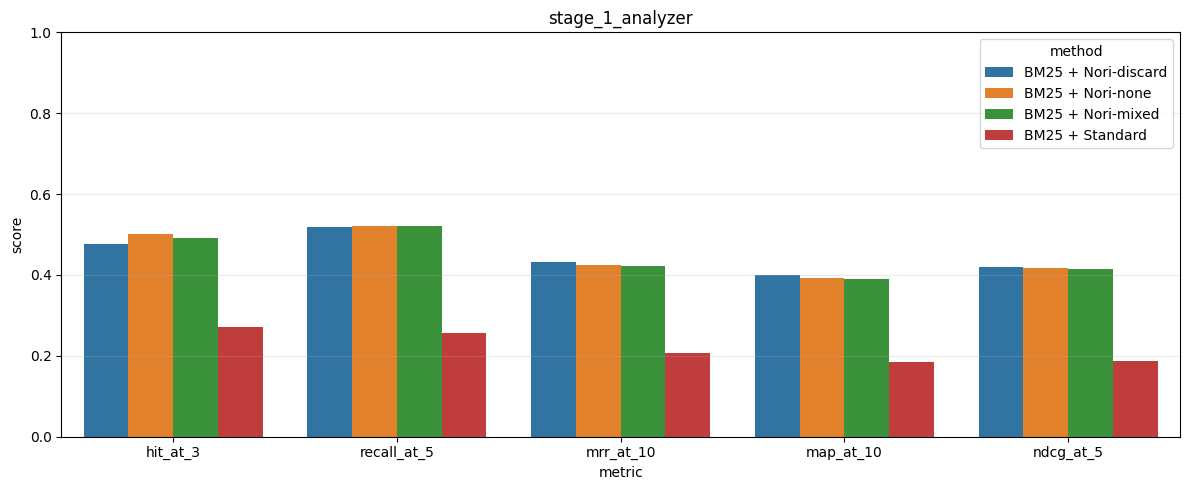

Best Analyzer: discard


In [ ]:

from kdic_retrieval_eval import ElasticsearchRetriever

stage1_name = "stage_1_analyzer"
stage1_retrievers = {
    method: ElasticsearchRetriever(
        es,
        index_name=INDEX_BY_ANALYZER[mode],
        method="bm25",
    )
    for method, mode in ANALYZER_MODES.items()
}
stage1_results = {
    method: evaluate_and_save(stage1_name, method, retriever)
    for method, retriever in stage1_retrievers.items()
}
best_analyzer_method, stage1_leaderboard = select_stage(
    stage1_name,
    stage1_results,
)
best_analyzer_mode = ANALYZER_MODES[best_analyzer_method]
best_analyzer_index = INDEX_BY_ANALYZER[best_analyzer_mode]
plot_leaderboard(stage1_name)

print("Best Analyzer:", best_analyzer_mode)


## 8. HCX BGE-M3 Dense와 로컬 BGE-M3 Sparse 표현 생성

### Dense

- Colab Secrets의 `HCX_API_KEY`를 사용합니다.
- OpenAI 호환 Base URL: `https://clovastudio.stream.ntruss.com/v1/openai`
- 모델명: `bge-m3`
- 출력: 1024차원 dense 벡터
- `Dense-content`: 본문만 사용하며 기존 `chunk_embeddings_hcx.jsonl`이 입력 해시까지 일치하면 재사용
- `Dense-structured-v1`: 제목+소제목+본문
- `Dense-structured-v2`: 업무+청크 유형+제목+소제목+조건부 메타데이터+본문
- 평가 질문: 원문 질문을 HCX API로 한 번만 임베딩하고 모든 Dense/Hybrid 실험에서 공유

Structured V2에 포함하는 조건부 메타데이터는 `applicant_type`, `scenario`,
`document_category`이며 실제 값이 존재할 때만 입력에 포함합니다.
`chunk_id`, URL, 해시, 인덱스 번호는 의미 검색의 잡음이 될 수 있어 제외합니다.

### Sparse

HCX API는 BGE-M3의 dense 출력만 제공하므로 `BGE-M3 Sparse-structured`는
로컬 `BAAI/bge-m3`에서 sparse lexical weight를 생성합니다.


In [ ]:
import os

import torch
from FlagEmbedding import BGEM3FlagModel
from openai import OpenAI

from kdic_retrieval_eval import (
    BGESparseRetriever,
    HCXDenseRetriever,
    encode_bge_sparse_documents,
    build_structured_text_v2,
    encode_hcx_dense_documents,
    precompute_hcx_query_embeddings,
)

try:
    if IS_COLAB:
        from google.colab import userdata
        HCX_API_KEY = userdata.get("HCX_API_KEY")
    else:
        HCX_API_KEY = os.getenv("HCX_API_KEY")
except Exception:
    HCX_API_KEY = os.getenv("HCX_API_KEY")

if not HCX_API_KEY:
    raise RuntimeError(
        "HCX_API_KEY가 없습니다. Colab 왼쪽 Secrets에 HCX_API_KEY를 등록하세요."
    )

hcx_client = OpenAI(
    api_key=HCX_API_KEY,
    base_url=HCX_BASE_URL,
    timeout=HCX_REQUEST_TIMEOUT_SECONDS,
    max_retries=HCX_MAX_RETRIES,
)

print("HCX Base URL:", HCX_BASE_URL)
print("HCX Dense 모델:", HCX_EMBEDDING_MODEL)
print("HCX API 키:", "등록됨")

precomputed_hcx_path = chunks_path.parent / "chunk_embeddings_hcx.jsonl"
print("기존 HCX content 임베딩:", precomputed_hcx_path)

hcx_content_documents = encode_hcx_dense_documents(
    chunks,
    client=hcx_client,
    model_name=HCX_EMBEDDING_MODEL,
    dimensions=HCX_EMBEDDING_DIMENSIONS,
    cache_dir=WORK_DIR / "hcx_dense_cache",
    text_mode="content",
    precomputed_content_path=precomputed_hcx_path,
    max_input_chars=HCX_EMBEDDING_MAX_INPUT_CHARS,
    request_delay_seconds=HCX_EMBEDDING_REQUEST_DELAY_SECONDS,
    report_path=OUTPUT_ROOT / "hcx_document_embedding_content_report.csv",
)

hcx_structured_documents = encode_hcx_dense_documents(
    chunks,
    client=hcx_client,
    model_name=HCX_EMBEDDING_MODEL,
    dimensions=HCX_EMBEDDING_DIMENSIONS,
    cache_dir=WORK_DIR / "hcx_dense_cache",
    text_mode="structured",
    precomputed_content_path=None,
    max_input_chars=HCX_EMBEDDING_MAX_INPUT_CHARS,
    request_delay_seconds=HCX_EMBEDDING_REQUEST_DELAY_SECONDS,
    report_path=OUTPUT_ROOT / "hcx_document_embedding_structured_report.csv",
)

hcx_structured_v2_documents = encode_hcx_dense_documents(
    chunks,
    client=hcx_client,
    model_name=HCX_EMBEDDING_MODEL,
    dimensions=HCX_EMBEDDING_DIMENSIONS,
    cache_dir=WORK_DIR / "hcx_dense_cache",
    text_mode="structured_v2",
    precomputed_content_path=None,
    max_input_chars=HCX_EMBEDDING_MAX_INPUT_CHARS,
    request_delay_seconds=HCX_EMBEDDING_REQUEST_DELAY_SECONDS,
    report_path=OUTPUT_ROOT / "hcx_document_embedding_structured_v2_report.csv",
)

# Structured V2에 실제로 어떤 필드가 얼마나 포함되는지 기록합니다.
structured_v2_fields = [
    "business_function",
    "chunk_type",
    "title",
    "section_title",
    "applicant_type",
    "scenario",
    "document_category",
    "content",
]
structured_v2_coverage_rows = []
for field in structured_v2_fields:
    present_count = sum(
        1
        for chunk in chunks
        if str(chunk.get(field) or "").strip()
        and str(chunk.get(field) or "").strip().lower()
        not in {"none", "nan", "null", "<na>"}
    )
    structured_v2_coverage_rows.append(
        {
            "field": field,
            "present_count": present_count,
            "chunk_count": len(chunks),
            "coverage_rate": present_count / len(chunks),
        }
    )

structured_v2_field_coverage = pd.DataFrame(structured_v2_coverage_rows)
structured_v2_field_coverage.to_csv(
    OUTPUT_ROOT / "hcx_structured_v2_field_coverage.csv",
    index=False,
    encoding="utf-8-sig",
)

structured_v2_preview = pd.DataFrame(
    [
        {
            "chunk_id": str(chunk["chunk_id"]),
            "structured_v2_text": build_structured_text_v2(chunk),
        }
        for chunk in chunks[:20]
    ]
)
structured_v2_preview.to_csv(
    OUTPUT_ROOT / "hcx_structured_v2_preview.csv",
    index=False,
    encoding="utf-8-sig",
)

hcx_query_embeddings, hcx_query_embedding_report = precompute_hcx_query_embeddings(
    eval_df["question"].astype(str).tolist(),
    client=hcx_client,
    model_name=HCX_EMBEDDING_MODEL,
    dimensions=HCX_EMBEDDING_DIMENSIONS,
    cache_dir=WORK_DIR / "hcx_query_cache",
    max_input_chars=HCX_EMBEDDING_MAX_INPUT_CHARS,
    request_delay_seconds=HCX_EMBEDDING_REQUEST_DELAY_SECONDS,
)
hcx_query_embedding_report.to_csv(
    OUTPUT_ROOT / "hcx_query_embedding_latency.csv",
    index=False,
    encoding="utf-8-sig",
)

hcx_dense_content_retriever = HCXDenseRetriever(
    documents=hcx_content_documents,
    query_embeddings=hcx_query_embeddings,
)
hcx_dense_structured_retriever = HCXDenseRetriever(
    documents=hcx_structured_documents,
    query_embeddings=hcx_query_embeddings,
)
hcx_dense_structured_v2_retriever = HCXDenseRetriever(
    documents=hcx_structured_v2_documents,
    query_embeddings=hcx_query_embeddings,
)

# Sparse lexical weight만 로컬 BGE-M3에서 생성
use_fp16 = bool(torch.cuda.is_available())
print("CUDA:", torch.cuda.is_available(), "| Sparse use_fp16:", use_fp16)

bge_sparse_model = BGEM3FlagModel(
    BGE_SPARSE_MODEL_NAME,
    use_fp16=use_fp16,
)
bge_sparse_documents = encode_bge_sparse_documents(
    chunks,
    model=bge_sparse_model,
    model_name=BGE_SPARSE_MODEL_NAME,
    max_length=BGE_MAX_LENGTH,
    batch_size=BGE_BATCH_SIZE,
    cache_dir=WORK_DIR / "bge_sparse_cache",
    text_mode="structured",
)
bge_sparse_retriever = BGESparseRetriever(
    model=bge_sparse_model,
    documents=bge_sparse_documents,
    max_length=BGE_MAX_LENGTH,
)

print("HCX Content Dense shape:", hcx_content_documents.dense.shape)
print("HCX Structured V1 Dense shape:", hcx_structured_documents.dense.shape)
print("HCX Structured V2 Dense shape:", hcx_structured_v2_documents.dense.shape)
print("HCX Content source:", hcx_content_documents.source)
print("HCX Structured V1 source:", hcx_structured_documents.source)
print("HCX Structured V2 source:", hcx_structured_v2_documents.source)
print("Structured V2 필드 커버리지:")
display(structured_v2_field_coverage)
print("BGE Sparse docs:", len(bge_sparse_documents.lexical_weights))
print("평가 질문 임베딩 수:", len(hcx_query_embeddings))
display(hcx_query_embedding_report.describe(include="all"))


HCX Base URL: https://clovastudio.stream.ntruss.com/v1/openai
HCX Dense 모델: bge-m3
HCX API 키: 등록됨
기존 HCX content 임베딩: /content/kdic_retrieval_work/extracted_kdic_output/KDIC_output/processed/chunk_embeddings_hcx.jsonl
HCX 질문 임베딩 1/126
HCX 질문 임베딩 25/126
HCX 질문 임베딩 50/126
HCX 질문 임베딩 75/126
HCX 질문 임베딩 100/126
HCX 질문 임베딩 125/126
HCX 질문 임베딩 126/126
CUDA: True | Sparse use_fp16: True


Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

HCX Content Dense shape: (427, 1024)
HCX Structured Dense shape: (427, 1024)
HCX Content source: precomputed_chunk_embeddings_hcx.jsonl
HCX Structured source: hcx_api
BGE Sparse docs: 427
평가 질문 임베딩 수: 126


,question,cache_hit,source,api_latency_ms
count,126,126,126,126.0
unique,126,1,1,NaN
top,예금자 1인당 보호받을 수 있는 한도는 얼마인가요?,True,item_cache,NaN
freq,1,126,126,NaN
mean,NaN,NaN,NaN,0.0
std,NaN,NaN,NaN,0.0
min,NaN,NaN,NaN,0.0
25%,NaN,NaN,NaN,0.0
50%,NaN,NaN,NaN,0.0
75%,NaN,NaN,NaN,0.0


## 9. 2차 비교 — 최적 Sparse 구조 선택


[stage_2_sparse] BM25 + discard 평가 시작
[stage_2_sparse] BM25 + discard 완료
[stage_2_sparse] BM25F + discard 평가 시작
[stage_2_sparse] BM25F + discard 완료
[stage_2_sparse] BGE-M3 Sparse-structured (local) 평가 시작


pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 227.91it/s]
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 59.74it/s]


[stage_2_sparse] BGE-M3 Sparse-structured (local) 완료
선정 범위: all(no split column or matching split)
1위: BGE-M3 Sparse-structured (local)


,method,ndcg_at_5,recall_at_5,primary_recall_at_5,mrr_at_10,map_at_10,latency_ms_p50,context_limit_exceeded_rate
0,BGE-M3 Sparse-structured (local),0.443451,0.554762,0.562434,0.457502,0.418137,47.208094,0.0
1,BM25F + discard,0.428879,0.522751,0.537302,0.439191,0.405920,5.453927,0.0
2,BM25 + discard,0.420529,0.518783,0.525397,0.433088,0.400311,2.952815,0.0


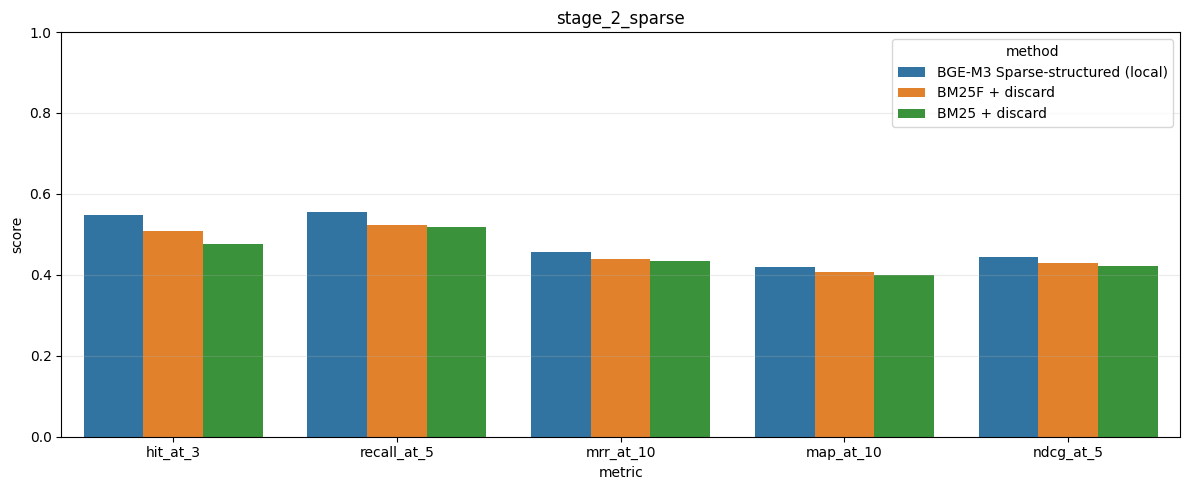

Best Sparse: BGE-M3 Sparse-structured (local)


In [ ]:
stage2_name = "stage_2_sparse"

bm25_best = ElasticsearchRetriever(
    es,
    index_name=best_analyzer_index,
    method="bm25",
)
bm25f_best = ElasticsearchRetriever(
    es,
    index_name=best_analyzer_index,
    method="bm25f",
    field_boosts=BM25F_FIELD_BOOSTS,
)

stage2_retrievers = {
    f"BM25 + {best_analyzer_mode}": bm25_best,
    f"BM25F + {best_analyzer_mode}": bm25f_best,
    "BGE-M3 Sparse-structured (local)": bge_sparse_retriever,
}
stage2_results = {
    method: evaluate_and_save(stage2_name, method, retriever)
    for method, retriever in stage2_retrievers.items()
}
best_sparse_method, stage2_leaderboard = select_stage(
    stage2_name,
    stage2_results,
)
best_sparse_retriever = stage2_retrievers[best_sparse_method]
plot_leaderboard(stage2_name)

print("Best Sparse:", best_sparse_method)


## 10. 3차 비교 — 최적 Dense 입력 선택

동일한 HCX `bge-m3` 모델과 동일한 질문 벡터를 사용하고 문서 입력 형식만 비교합니다.

1. `Dense-content`: 본문
2. `Dense-structured-v1`: 제목 + 소제목 + 본문
3. `Dense-structured-v2`: 업무 + 청크 유형 + 제목 + 소제목 +
   신청인 유형/상황/서류 구분(존재 시) + 본문

3차 승자는 4단계 Hybrid의 Dense 축으로 자동 전달됩니다.


[stage_3_dense_hcx] HCX bge-m3 Dense-content 평가 시작
[stage_3_dense_hcx] HCX bge-m3 Dense-content 완료
[stage_3_dense_hcx] HCX bge-m3 Dense-structured 평가 시작
[stage_3_dense_hcx] HCX bge-m3 Dense-structured 완료
선정 범위: all(no split column or matching split)
1위: HCX bge-m3 Dense-structured


,method,ndcg_at_5,recall_at_5,primary_recall_at_5,mrr_at_10,map_at_10,latency_ms_p50,context_limit_exceeded_rate
0,HCX bge-m3 Dense-structured,0.603849,0.724868,0.743122,0.602179,0.560493,0.145225,0.0
1,HCX bge-m3 Dense-content,0.550377,0.669312,0.687566,0.565127,0.517720,0.149348,0.0


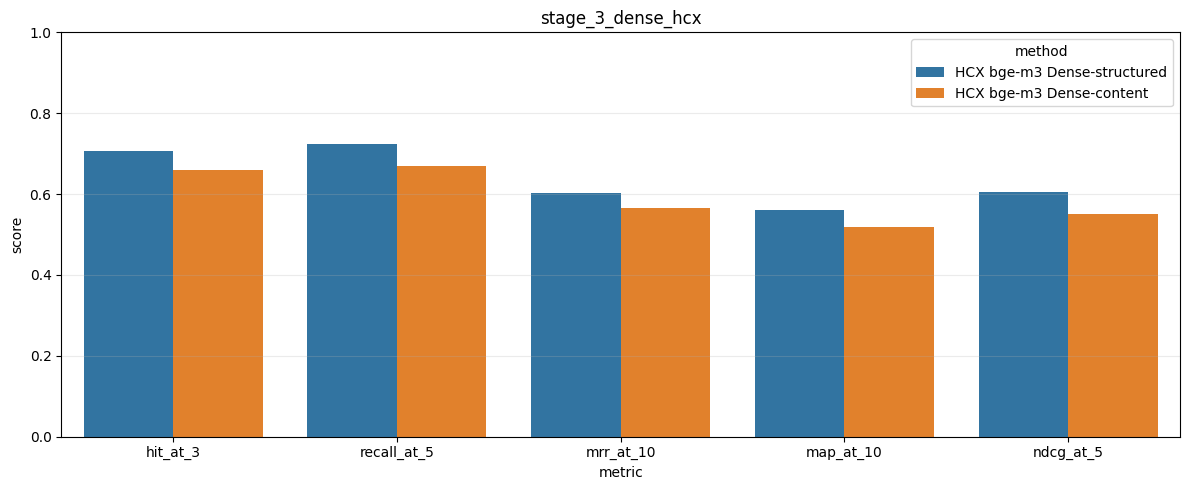

Best Dense: HCX bge-m3 Dense-structured


In [ ]:
stage3_name = "stage_3_dense_hcx"
stage3_retrievers = {
    "HCX bge-m3 Dense-content": hcx_dense_content_retriever,
    "HCX bge-m3 Dense-structured-v1": hcx_dense_structured_retriever,
    "HCX bge-m3 Dense-structured-v2": hcx_dense_structured_v2_retriever,
}
stage3_results = {
    method: evaluate_and_save(stage3_name, method, retriever)
    for method, retriever in stage3_retrievers.items()
}
best_dense_method, stage3_leaderboard = select_stage(
    stage3_name,
    stage3_results,
)
best_dense_retriever = stage3_retrievers[best_dense_method]
plot_leaderboard(stage3_name)

print("Best Dense:", best_dense_method)


## 11. Dual Hybrid 튜닝용 기본 순위 캐시

4단계에서는 RRF_K, 가중치, 후보 depth만 바꾸기 위해 Dense와 Sparse 기본 순위를
질문별로 한 번만 계산합니다.

- Dense: 3차 `Dense-content / structured-v1 / structured-v2` 비교 승자
- Sparse 계열 A: `BGE-M3 Sparse-structured (local)`
- Sparse 계열 B: `BM25 + Nori-none/discard` 중 우수 방식


In [ ]:
from kdic_retrieval_eval import CachedRetriever, collect_rankings

MAX_HYBRID_DEPTH = max(
    max(HYBRID_DEPTHS),
    HYBRID_WEIGHT_DEPTH,
    RRF_K_COMPARISON_DEPTH,
)

# 3차 Dense 비교 승자를 4단계 Hybrid의 Dense 축으로 자동 전달합니다.
HYBRID_DENSE_METHOD = best_dense_method
hybrid_dense_retriever = best_dense_retriever

# BM25 Hybrid 축은 Nori-none과 Nori-discard 중 동일 선정 기준에서 더 높은 방식을 사용합니다.
bm25_hybrid_candidate_methods = [
    "BM25 + Nori-none",
    "BM25 + Nori-discard",
]
bm25_hybrid_board = stage1_leaderboard[
    stage1_leaderboard["method"].isin(bm25_hybrid_candidate_methods)
].copy()
if bm25_hybrid_board.empty:
    raise RuntimeError("BM25 Hybrid 후보인 Nori-none/discard 평가 결과가 없습니다.")

BM25_HYBRID_METHOD = str(bm25_hybrid_board.iloc[0]["method"])
BM25_HYBRID_MODE = ANALYZER_MODES[BM25_HYBRID_METHOD]
bm25_hybrid_retriever = stage1_retrievers[BM25_HYBRID_METHOD]

BGE_SPARSE_FAMILY = "BGE-M3 Sparse"
BM25_SPARSE_FAMILY = f"BM25 Nori-{BM25_HYBRID_MODE}"

hybrid_sparse_families = {
    BGE_SPARSE_FAMILY: {
        "sparse_method": "BGE-M3 Sparse-structured (local)",
        "retriever": bge_sparse_retriever,
    },
    BM25_SPARSE_FAMILY: {
        "sparse_method": BM25_HYBRID_METHOD,
        "retriever": bm25_hybrid_retriever,
    },
}

hybrid_dense_rankings = collect_rankings(
    retriever=hybrid_dense_retriever,
    eval_df=eval_df,
    config=CONFIG,
    depth=MAX_HYBRID_DEPTH,
)
cached_hybrid_dense = CachedRetriever(hybrid_dense_rankings)

hybrid_sparse_rankings_by_family = {}
cached_hybrid_sparse_by_family = {}
for family, spec in hybrid_sparse_families.items():
    rankings = collect_rankings(
        retriever=spec["retriever"],
        eval_df=eval_df,
        config=CONFIG,
        depth=MAX_HYBRID_DEPTH,
    )
    hybrid_sparse_rankings_by_family[family] = rankings
    cached_hybrid_sparse_by_family[family] = CachedRetriever(rankings)

print("Hybrid Dense:", HYBRID_DENSE_METHOD)
print("BM25 Hybrid 후보 비교:")
display(
    bm25_hybrid_board[
        ["method", "ndcg_at_5", "recall_at_5", "mrr_at_10", "latency_ms_p50"]
    ]
)
print("BM25 Hybrid 선택:", BM25_HYBRID_METHOD)
print("Dense 캐시 질문 수:", len(hybrid_dense_rankings))
for family, rankings in hybrid_sparse_rankings_by_family.items():
    print(f"{family} 캐시 질문 수:", len(rankings))


Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 56.15it/s]


Hybrid Dense: HCX bge-m3 Dense-structured
BM25 Hybrid 후보 비교:


,method,ndcg_at_5,recall_at_5,mrr_at_10,latency_ms_p50
0,BM25 + Nori-discard,0.420529,0.518783,0.433088,12.426252
1,BM25 + Nori-none,0.417945,0.520370,0.424795,3.501643


BM25 Hybrid 선택: BM25 + Nori-discard
Dense 캐시 질문 수: 126
BGE-M3 Sparse 캐시 질문 수: 126
BM25 Nori-discard 캐시 질문 수: 126


## 12. 4-0차 — Dual Hybrid RRF_K 비교

가중치와 후보 깊이가 RRF_K 실험에 영향을 주지 않도록 다음을 고정합니다.

- Dense weight: 0.50
- Sparse weight: 0.50
- Candidate depth: 30
- RRF_K 후보: 10, 20, 30, 40, 60, 80, 100

두 Sparse 계열은 서로 순위 분포가 다르므로 **계열별 Best RRF_K를 따로 선정**합니다.


[stage_4_0_dual_hybrid_rrf_k] Hybrid[BGE-M3 Sparse] RRFk10 D0.50 S0.50 depth30 평가 시작
[stage_4_0_dual_hybrid_rrf_k] Hybrid[BGE-M3 Sparse] RRFk10 D0.50 S0.50 depth30 완료
[stage_4_0_dual_hybrid_rrf_k] Hybrid[BGE-M3 Sparse] RRFk20 D0.50 S0.50 depth30 평가 시작
[stage_4_0_dual_hybrid_rrf_k] Hybrid[BGE-M3 Sparse] RRFk20 D0.50 S0.50 depth30 완료
[stage_4_0_dual_hybrid_rrf_k] Hybrid[BGE-M3 Sparse] RRFk30 D0.50 S0.50 depth30 평가 시작
[stage_4_0_dual_hybrid_rrf_k] Hybrid[BGE-M3 Sparse] RRFk30 D0.50 S0.50 depth30 완료
[stage_4_0_dual_hybrid_rrf_k] Hybrid[BGE-M3 Sparse] RRFk40 D0.50 S0.50 depth30 평가 시작
[stage_4_0_dual_hybrid_rrf_k] Hybrid[BGE-M3 Sparse] RRFk40 D0.50 S0.50 depth30 완료
[stage_4_0_dual_hybrid_rrf_k] Hybrid[BGE-M3 Sparse] RRFk60 D0.50 S0.50 depth30 평가 시작
[stage_4_0_dual_hybrid_rrf_k] Hybrid[BGE-M3 Sparse] RRFk60 D0.50 S0.50 depth30 완료
[stage_4_0_dual_hybrid_rrf_k] Hybrid[BGE-M3 Sparse] RRFk80 D0.50 S0.50 depth30 평가 시작
[stage_4_0_dual_hybrid_rrf_k] Hybrid[BGE-M3 Sparse] RRFk80 D0.50 S0.50 depth30 완

,method,ndcg_at_5,recall_at_5,primary_recall_at_5,mrr_at_10,map_at_10,latency_ms_p50,context_limit_exceeded_rate
0,Hybrid[BM25 Nori-discard] RRFk10 D0.50 S0.50 d...,0.562538,0.677249,0.703439,0.567763,0.537358,0.067405,0.0
1,Hybrid[BM25 Nori-discard] RRFk20 D0.50 S0.50 d...,0.546699,0.665344,0.687566,0.551449,0.521077,0.066883,0.0
2,Hybrid[BM25 Nori-discard] RRFk30 D0.50 S0.50 d...,0.545827,0.658995,0.681217,0.552475,0.522535,0.065581,0.0
3,Hybrid[BM25 Nori-discard] RRFk40 D0.50 S0.50 d...,0.541405,0.651058,0.673280,0.549786,0.520021,0.064940,0.0
4,Hybrid[BM25 Nori-discard] RRFk60 D0.50 S0.50 d...,0.538375,0.647090,0.669312,0.548277,0.517833,0.067915,0.0
5,Hybrid[BM25 Nori-discard] RRFk100 D0.50 S0.50 ...,0.538375,0.647090,0.669312,0.548199,0.517611,0.071494,0.0
6,Hybrid[BM25 Nori-discard] RRFk80 D0.50 S0.50 d...,0.538375,0.647090,0.669312,0.548088,0.517555,0.066553,0.0
7,Hybrid[BGE-M3 Sparse] RRFk20 D0.50 S0.50 depth30,0.510265,0.656085,0.662434,0.511681,0.474502,0.066370,0.0
8,Hybrid[BGE-M3 Sparse] RRFk10 D0.50 S0.50 depth30,0.508234,0.648148,0.654497,0.516134,0.478195,0.062846,0.0
9,Hybrid[BGE-M3 Sparse] RRFk30 D0.50 S0.50 depth30,0.505938,0.648148,0.654497,0.510349,0.472773,0.067308,0.0


4-0차 전체 1위: Hybrid[BM25 Nori-discard] RRFk10 D0.50 S0.50 depth30
4-1차로 전달할 계열별 Best RRF_K:


,hybrid_family,sparse_method,rrf_k,ndcg_at_5,recall_at_5,primary_recall_at_5,mrr_at_10,complete_at_5
0,BGE-M3 Sparse,BGE-M3 Sparse-structured (local),20,0.510265,0.656085,0.662434,0.511681,0.386364
1,BM25 Nori-discard,BM25 + Nori-discard,10,0.562538,0.677249,0.703439,0.567763,0.363636


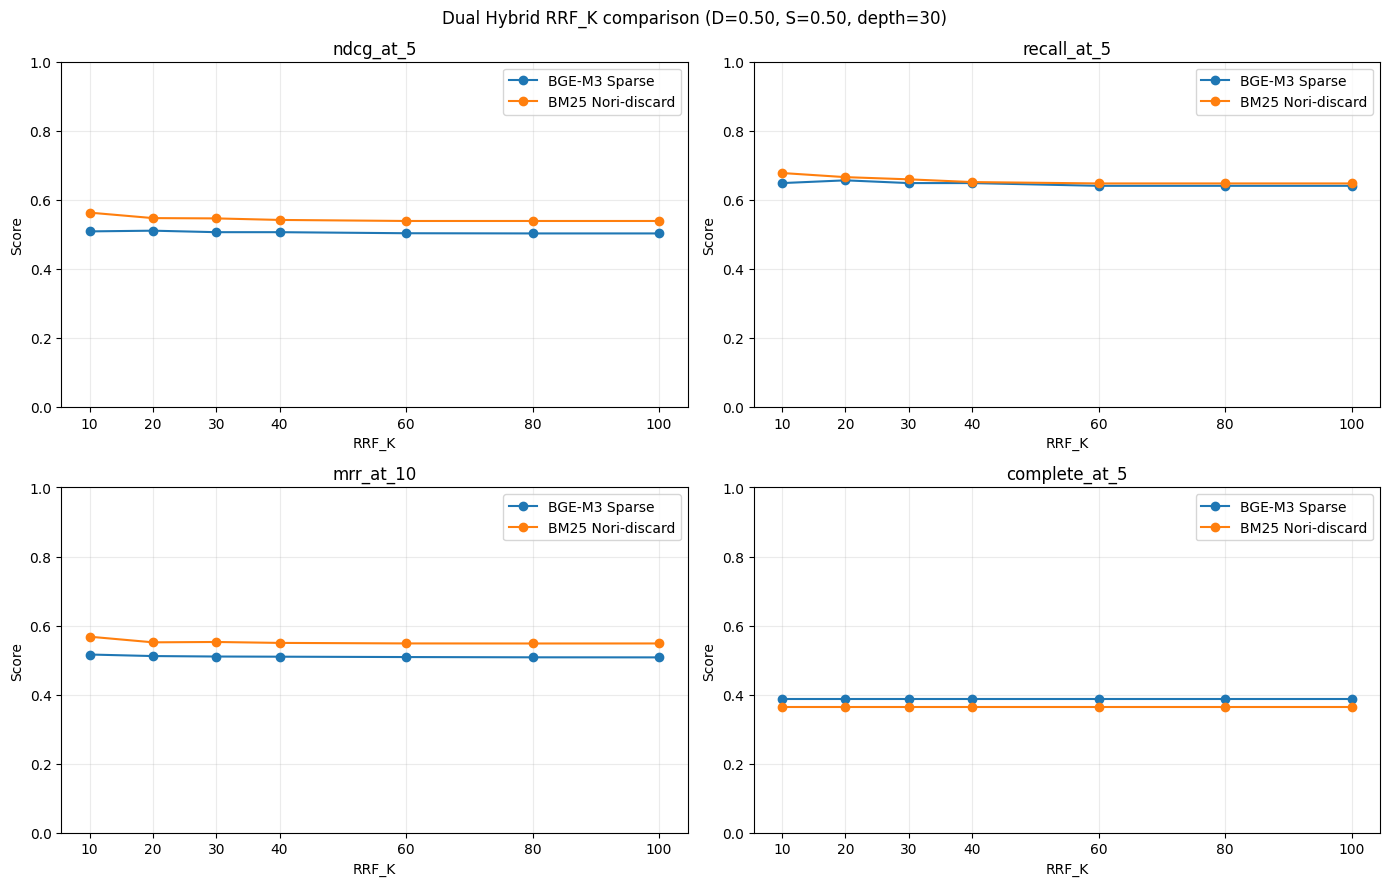

In [ ]:
from kdic_retrieval_eval import HybridRRFRetriever


def make_hybrid_method_name(
    family: str,
    dense_weight: float,
    sparse_weight: float,
    candidate_depth: int,
    rrf_k: int,
) -> str:
    return (
        f"Hybrid[{family}] "
        f"RRFk{rrf_k} "
        f"D{dense_weight:.2f} S{sparse_weight:.2f} "
        f"depth{candidate_depth}"
    )


stage40_name = "stage_4_0_dual_hybrid_rrf_k"
stage40_retrievers = {}
stage40_configs = {}

for family, family_spec in hybrid_sparse_families.items():
    for rrf_k in RRF_K_CANDIDATES:
        method = make_hybrid_method_name(
            family,
            RRF_K_BASE_DENSE_WEIGHT,
            RRF_K_BASE_SPARSE_WEIGHT,
            RRF_K_COMPARISON_DEPTH,
            rrf_k,
        )
        stage40_configs[method] = {
            "hybrid_family": family,
            "dense_method": HYBRID_DENSE_METHOD,
            "sparse_method": family_spec["sparse_method"],
            "rrf_k": rrf_k,
            "dense_weight": RRF_K_BASE_DENSE_WEIGHT,
            "sparse_weight": RRF_K_BASE_SPARSE_WEIGHT,
            "candidate_depth": RRF_K_COMPARISON_DEPTH,
        }
        stage40_retrievers[method] = HybridRRFRetriever(
            cached_hybrid_dense,
            cached_hybrid_sparse_by_family[family],
            candidate_depth=RRF_K_COMPARISON_DEPTH,
            rrf_k=rrf_k,
            dense_weight=RRF_K_BASE_DENSE_WEIGHT,
            sparse_weight=RRF_K_BASE_SPARSE_WEIGHT,
        )

expected_rrf_method_count = len(hybrid_sparse_families) * len(RRF_K_CANDIDATES)
assert len(stage40_retrievers) == expected_rrf_method_count

stage40_results = {
    method: evaluate_and_save(stage40_name, method, retriever)
    for method, retriever in stage40_retrievers.items()
}
best_rrf_method_overall, stage40_leaderboard = select_stage(
    stage40_name,
    stage40_results,
)

for column in [
    "hybrid_family",
    "dense_method",
    "sparse_method",
    "rrf_k",
    "dense_weight",
    "sparse_weight",
    "candidate_depth",
]:
    stage40_leaderboard[column] = stage40_leaderboard["method"].map(
        lambda method: stage40_configs[method][column]
    )

stage_leaderboards[stage40_name] = stage40_leaderboard
stage40_dir = OUTPUT_ROOT / stage40_name
stage40_leaderboard.to_csv(
    stage40_dir / "leaderboard.csv",
    index=False,
    encoding="utf-8-sig",
)
stage40_leaderboard.to_csv(
    stage40_dir / "rrf_k_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

best_rrf_methods_by_family = {}
best_rrf_k_by_family = {}
best_rrf_configs_by_family = {}
rrf_family_winner_rows = []

for family in hybrid_sparse_families:
    family_board = stage40_leaderboard[
        stage40_leaderboard["hybrid_family"] == family
    ]
    if family_board.empty:
        raise RuntimeError(f"RRF_K 결과가 없습니다: {family}")
    best_method = str(family_board.iloc[0]["method"])
    best_rrf_methods_by_family[family] = best_method
    best_rrf_configs_by_family[family] = stage40_configs[best_method]
    best_rrf_k_by_family[family] = int(stage40_configs[best_method]["rrf_k"])
    rrf_family_winner_rows.append(family_board.iloc[0])

stage40_family_winners = pd.DataFrame(rrf_family_winner_rows).reset_index(drop=True)
stage40_family_winners.to_csv(
    stage40_dir / "family_winners.csv",
    index=False,
    encoding="utf-8-sig",
)

print("4-0차 전체 1위:", best_rrf_method_overall)
print("4-1차로 전달할 계열별 Best RRF_K:")
display(
    stage40_family_winners[
        [
            "hybrid_family",
            "sparse_method",
            "rrf_k",
            "ndcg_at_5",
            "recall_at_5",
            "primary_recall_at_5",
            "mrr_at_10",
            "complete_at_5",
        ]
    ]
)

rrf_plot_metrics = [
    "ndcg_at_5",
    "recall_at_5",
    "mrr_at_10",
    "complete_at_5",
]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, metric in zip(axes.flat, rrf_plot_metrics):
    for family in hybrid_sparse_families:
        subset = stage40_leaderboard[
            stage40_leaderboard["hybrid_family"] == family
        ].sort_values("rrf_k")
        axis.plot(
            subset["rrf_k"],
            subset[metric],
            marker="o",
            label=family,
        )
    axis.set_title(metric)
    axis.set_xlabel("RRF_K")
    axis.set_ylabel("Score")
    axis.set_xticks(RRF_K_CANDIDATES)
    axis.set_ylim(0, 1)
    axis.grid(alpha=0.25)
    axis.legend()
fig.suptitle("Dual Hybrid RRF_K comparison (D=0.50, S=0.50, depth=30)")
fig.tight_layout()
fig.savefig(
    stage40_dir / "metric_comparison.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


## 13. 4-1차 — 계열별 Best RRF_K 기반 Dual Hybrid 가중치 비교

4-0차에서 선정한 계열별 Best RRF_K와 depth=30을 고정하고 다음 가중치를 비교합니다.

- Dense: 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95
- Sparse: 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.05


[stage_4_1_dual_hybrid_weights] Hybrid[BGE-M3 Sparse] RRFk20 D0.60 S0.40 depth30 평가 시작
[stage_4_1_dual_hybrid_weights] Hybrid[BGE-M3 Sparse] RRFk20 D0.60 S0.40 depth30 완료
[stage_4_1_dual_hybrid_weights] Hybrid[BGE-M3 Sparse] RRFk20 D0.65 S0.35 depth30 평가 시작
[stage_4_1_dual_hybrid_weights] Hybrid[BGE-M3 Sparse] RRFk20 D0.65 S0.35 depth30 완료
[stage_4_1_dual_hybrid_weights] Hybrid[BGE-M3 Sparse] RRFk20 D0.70 S0.30 depth30 평가 시작
[stage_4_1_dual_hybrid_weights] Hybrid[BGE-M3 Sparse] RRFk20 D0.70 S0.30 depth30 완료
[stage_4_1_dual_hybrid_weights] Hybrid[BGE-M3 Sparse] RRFk20 D0.75 S0.25 depth30 평가 시작
[stage_4_1_dual_hybrid_weights] Hybrid[BGE-M3 Sparse] RRFk20 D0.75 S0.25 depth30 완료
[stage_4_1_dual_hybrid_weights] Hybrid[BGE-M3 Sparse] RRFk20 D0.80 S0.20 depth30 평가 시작
[stage_4_1_dual_hybrid_weights] Hybrid[BGE-M3 Sparse] RRFk20 D0.80 S0.20 depth30 완료
[stage_4_1_dual_hybrid_weights] Hybrid[BGE-M3 Sparse] RRFk20 D0.85 S0.15 depth30 평가 시작
[stage_4_1_dual_hybrid_weights] Hybrid[BGE-M3 Sparse] RRFk

,method,ndcg_at_5,recall_at_5,primary_recall_at_5,mrr_at_10,map_at_10,latency_ms_p50,context_limit_exceeded_rate
0,Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth30,0.604665,0.720899,0.743122,0.601231,0.564714,0.060317,0.0
1,Hybrid[BGE-M3 Sparse] RRFk20 D0.95 S0.05 depth30,0.604399,0.724868,0.743122,0.602897,0.560417,0.065258,0.0
2,Hybrid[BGE-M3 Sparse] RRFk20 D0.85 S0.15 depth30,0.604213,0.731481,0.753704,0.598917,0.561000,0.067304,0.0
3,Hybrid[BM25 Nori-discard] RRFk10 D0.95 S0.05 d...,0.603849,0.724868,0.743122,0.602290,0.562311,0.069570,0.0
4,Hybrid[BM25 Nori-discard] RRFk10 D0.70 S0.30 d...,0.603138,0.701058,0.731217,0.617117,0.581071,0.072067,0.0
5,Hybrid[BM25 Nori-discard] RRFk10 D0.90 S0.10 d...,0.601624,0.724868,0.743122,0.603675,0.561321,0.068889,0.0
6,Hybrid[BM25 Nori-discard] RRFk10 D0.85 S0.15 d...,0.599639,0.708995,0.731217,0.610355,0.566080,0.069551,0.0
7,Hybrid[BM25 Nori-discard] RRFk10 D0.65 S0.35 d...,0.598895,0.701058,0.731217,0.612506,0.576658,0.074155,0.0
8,Hybrid[BGE-M3 Sparse] RRFk20 D0.80 S0.20 depth30,0.598629,0.721164,0.739418,0.595918,0.557861,0.065031,0.0
9,Hybrid[BM25 Nori-discard] RRFk10 D0.60 S0.40 d...,0.595292,0.695503,0.721693,0.611514,0.577786,0.070719,0.0


4-1차 전체 1위: Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth30
4-2차로 전달할 계열별 Best 가중치:


,hybrid_family,sparse_method,rrf_k,dense_weight,sparse_weight,ndcg_at_5,recall_at_5,primary_recall_at_5,mrr_at_10,complete_at_5
0,BGE-M3 Sparse,BGE-M3 Sparse-structured (local),20,0.90,0.10,0.604665,0.720899,0.743122,0.601231,0.363636
1,BM25 Nori-discard,BM25 + Nori-discard,10,0.95,0.05,0.603849,0.724868,0.743122,0.602290,0.386364


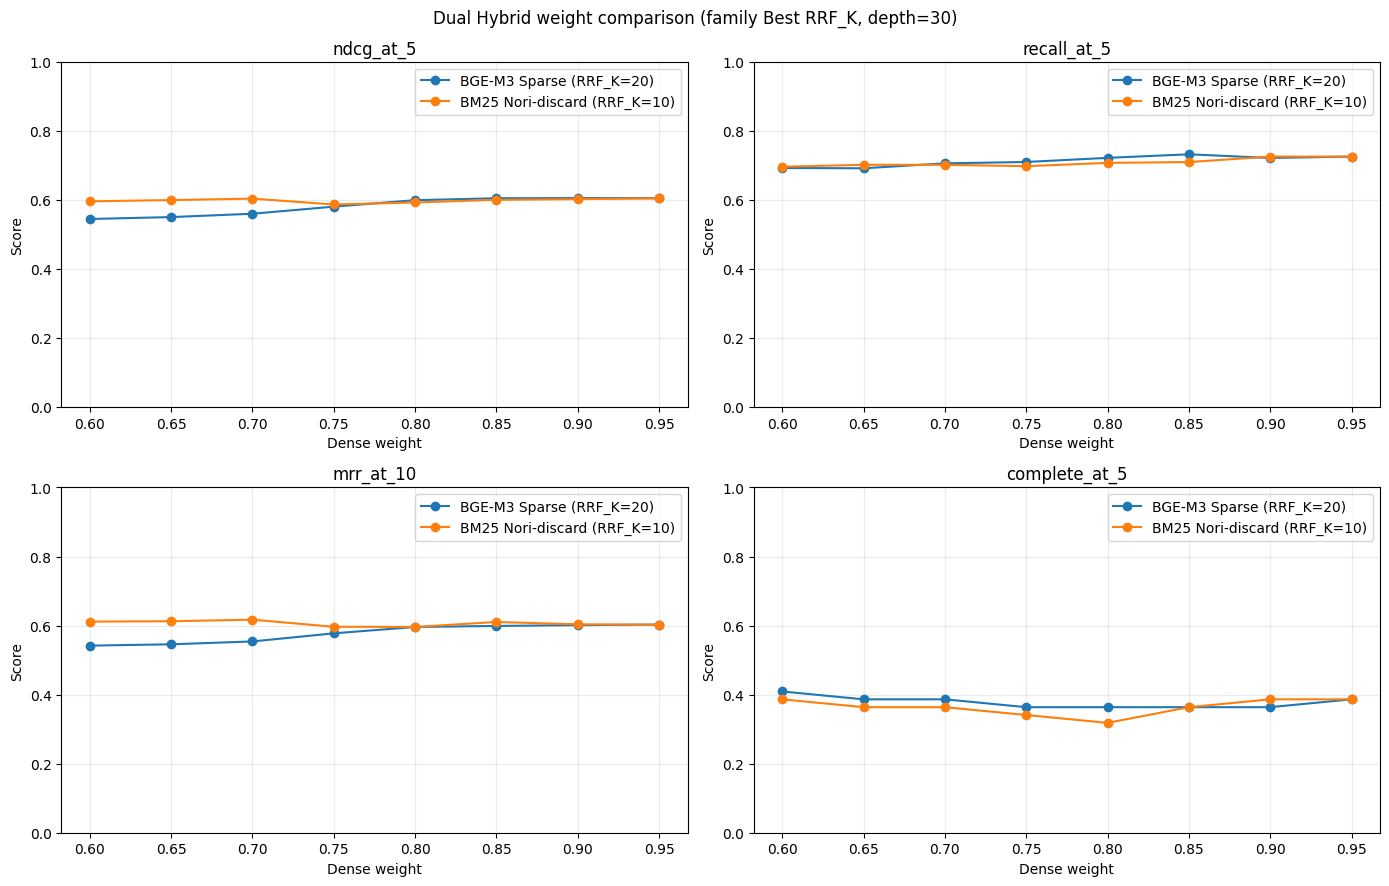

In [ ]:
stage41_name = "stage_4_1_dual_hybrid_weights"
stage41_retrievers = {}
stage41_configs = {}

for family, family_spec in hybrid_sparse_families.items():
    selected_rrf_k = best_rrf_k_by_family[family]
    for dense_weight, sparse_weight in HYBRID_WEIGHT_PAIRS:
        method = make_hybrid_method_name(
            family,
            dense_weight,
            sparse_weight,
            HYBRID_WEIGHT_DEPTH,
            selected_rrf_k,
        )
        stage41_configs[method] = {
            "hybrid_family": family,
            "dense_method": HYBRID_DENSE_METHOD,
            "sparse_method": family_spec["sparse_method"],
            "rrf_k": selected_rrf_k,
            "dense_weight": dense_weight,
            "sparse_weight": sparse_weight,
            "candidate_depth": HYBRID_WEIGHT_DEPTH,
        }
        stage41_retrievers[method] = HybridRRFRetriever(
            cached_hybrid_dense,
            cached_hybrid_sparse_by_family[family],
            candidate_depth=HYBRID_WEIGHT_DEPTH,
            rrf_k=selected_rrf_k,
            dense_weight=dense_weight,
            sparse_weight=sparse_weight,
        )

expected_method_count = len(hybrid_sparse_families) * len(HYBRID_WEIGHT_PAIRS)
assert len(stage41_retrievers) == expected_method_count == 16

stage41_results = {
    method: evaluate_and_save(stage41_name, method, retriever)
    for method, retriever in stage41_retrievers.items()
}
best_weight_method_overall, stage41_leaderboard = select_stage(
    stage41_name,
    stage41_results,
)

for column in [
    "hybrid_family",
    "dense_method",
    "sparse_method",
    "rrf_k",
    "dense_weight",
    "sparse_weight",
    "candidate_depth",
]:
    stage41_leaderboard[column] = stage41_leaderboard["method"].map(
        lambda method: stage41_configs[method][column]
    )

stage_leaderboards[stage41_name] = stage41_leaderboard
stage41_dir = OUTPUT_ROOT / stage41_name
stage41_leaderboard.to_csv(
    stage41_dir / "leaderboard.csv",
    index=False,
    encoding="utf-8-sig",
)
stage41_leaderboard.to_csv(
    stage41_dir / "hybrid_weight_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

best_weight_methods_by_family = {}
best_weight_configs_by_family = {}
family_winner_rows = []

for family in hybrid_sparse_families:
    family_board = stage41_leaderboard[
        stage41_leaderboard["hybrid_family"] == family
    ]
    if family_board.empty:
        raise RuntimeError(f"Hybrid 계열 결과가 없습니다: {family}")
    best_method = str(family_board.iloc[0]["method"])
    best_weight_methods_by_family[family] = best_method
    best_weight_configs_by_family[family] = stage41_configs[best_method]
    family_winner_rows.append(family_board.iloc[0])

stage41_family_winners = pd.DataFrame(family_winner_rows).reset_index(drop=True)
stage41_family_winners.to_csv(
    stage41_dir / "family_winners.csv",
    index=False,
    encoding="utf-8-sig",
)

print("4-1차 전체 1위:", best_weight_method_overall)
print("4-2차로 전달할 계열별 Best 가중치:")
display(
    stage41_family_winners[
        [
            "hybrid_family",
            "sparse_method",
            "rrf_k",
            "dense_weight",
            "sparse_weight",
            "ndcg_at_5",
            "recall_at_5",
            "primary_recall_at_5",
            "mrr_at_10",
            "complete_at_5",
        ]
    ]
)

weight_plot_metrics = [
    "ndcg_at_5",
    "recall_at_5",
    "mrr_at_10",
    "complete_at_5",
]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, metric in zip(axes.flat, weight_plot_metrics):
    for family in hybrid_sparse_families:
        subset = stage41_leaderboard[
            stage41_leaderboard["hybrid_family"] == family
        ].sort_values("dense_weight")
        axis.plot(
            subset["dense_weight"],
            subset[metric],
            marker="o",
            label=(
                f"{family} "
                f"(RRF_K={best_rrf_k_by_family[family]})"
            ),
        )
    axis.set_title(metric)
    axis.set_xlabel("Dense weight")
    axis.set_ylabel("Score")
    axis.set_xticks(HYBRID_DENSE_WEIGHTS)
    axis.set_ylim(0, 1)
    axis.grid(alpha=0.25)
    axis.legend()
fig.suptitle("Dual Hybrid weight comparison (family Best RRF_K, depth=30)")
fig.tight_layout()
fig.savefig(
    stage41_dir / "metric_comparison.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


## 14. 4-2차 — 계열별 Best RRF_K + Best 가중치 × depth 20/30/50

각 Hybrid 계열에서 4-0차 Best RRF_K와 4-1차 Best 가중치를 고정한 뒤,
RRF 결합 전 후보 깊이만 20, 30, 50으로 변경합니다.


[stage_4_2_dual_hybrid_depth] Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth20 평가 시작
[stage_4_2_dual_hybrid_depth] Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth20 완료
[stage_4_2_dual_hybrid_depth] Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth30 평가 시작
[stage_4_2_dual_hybrid_depth] Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth30 완료
[stage_4_2_dual_hybrid_depth] Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50 평가 시작
[stage_4_2_dual_hybrid_depth] Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50 완료
[stage_4_2_dual_hybrid_depth] Hybrid[BM25 Nori-discard] RRFk10 D0.95 S0.05 depth20 평가 시작
[stage_4_2_dual_hybrid_depth] Hybrid[BM25 Nori-discard] RRFk10 D0.95 S0.05 depth20 완료
[stage_4_2_dual_hybrid_depth] Hybrid[BM25 Nori-discard] RRFk10 D0.95 S0.05 depth30 평가 시작
[stage_4_2_dual_hybrid_depth] Hybrid[BM25 Nori-discard] RRFk10 D0.95 S0.05 depth30 완료
[stage_4_2_dual_hybrid_depth] Hybrid[BM25 Nori-discard] RRFk10 D0.95 S0.05 depth50 평가 시작
[stage_4_2_dual_hybrid_depth] Hybrid[BM25 Nori-discard] RRFk

,method,ndcg_at_5,recall_at_5,primary_recall_at_5,mrr_at_10,map_at_10,latency_ms_p50,context_limit_exceeded_rate
0,Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50,0.606135,0.720899,0.743122,0.606611,0.564714,0.096755,0.0
1,Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth20,0.605639,0.724868,0.743122,0.601672,0.563467,0.052373,0.0
2,Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth30,0.604665,0.720899,0.743122,0.601231,0.564714,0.069118,0.0
3,Hybrid[BM25 Nori-discard] RRFk10 D0.95 S0.05 d...,0.603849,0.724868,0.743122,0.602290,0.562311,0.070167,0.0
4,Hybrid[BM25 Nori-discard] RRFk10 D0.95 S0.05 d...,0.603849,0.724868,0.743122,0.602290,0.562311,0.105018,0.0
5,Hybrid[BM25 Nori-discard] RRFk10 D0.95 S0.05 d...,0.603288,0.724868,0.743122,0.601893,0.561628,0.052189,0.0


4-2차 전체 1위: Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50
5차로 전달할 계열별 Best Hybrid:


,hybrid_family,sparse_method,rrf_k,dense_weight,sparse_weight,candidate_depth,ndcg_at_5,recall_at_5,primary_recall_at_5,mrr_at_10,complete_at_5,latency_ms_p50
0,BGE-M3 Sparse,BGE-M3 Sparse-structured (local),20,0.90,0.10,50,0.606135,0.720899,0.743122,0.606611,0.363636,0.096755
1,BM25 Nori-discard,BM25 + Nori-discard,10,0.95,0.05,30,0.603849,0.724868,0.743122,0.602290,0.386364,0.070167


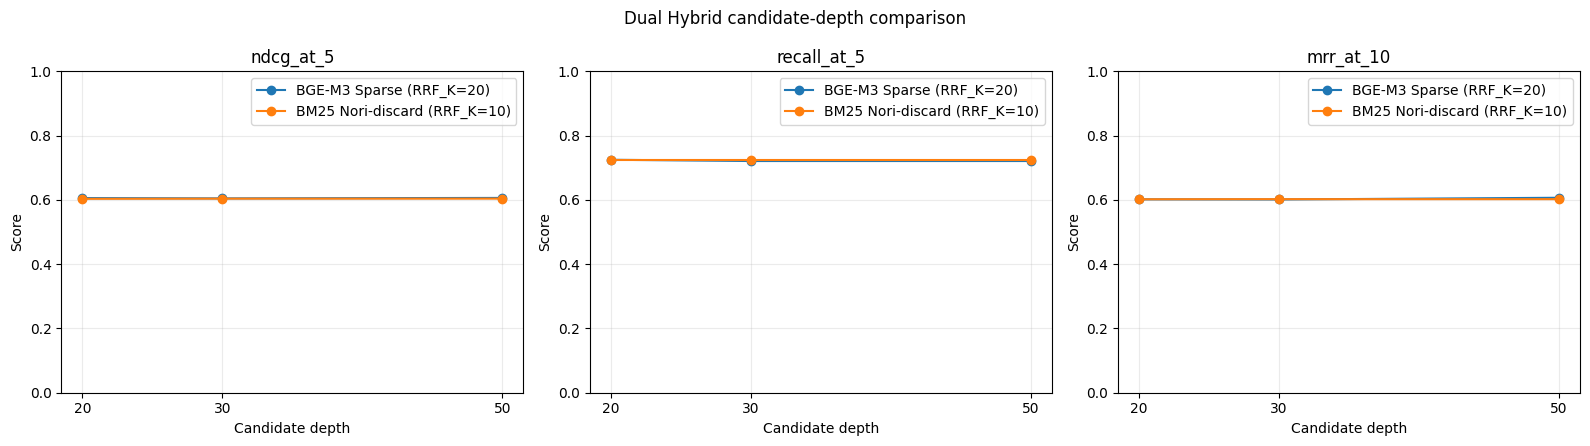

In [ ]:
stage42_name = "stage_4_2_dual_hybrid_depth"
stage42_retrievers = {}
stage42_configs = {}

for family, weight_config in best_weight_configs_by_family.items():
    dense_weight = weight_config["dense_weight"]
    sparse_weight = weight_config["sparse_weight"]
    selected_rrf_k = int(weight_config["rrf_k"])

    for candidate_depth in HYBRID_DEPTHS:
        method = make_hybrid_method_name(
            family,
            dense_weight,
            sparse_weight,
            candidate_depth,
            selected_rrf_k,
        )
        stage42_configs[method] = {
            **weight_config,
            "candidate_depth": candidate_depth,
        }
        stage42_retrievers[method] = HybridRRFRetriever(
            cached_hybrid_dense,
            cached_hybrid_sparse_by_family[family],
            candidate_depth=candidate_depth,
            rrf_k=selected_rrf_k,
            dense_weight=dense_weight,
            sparse_weight=sparse_weight,
        )

expected_depth_method_count = len(hybrid_sparse_families) * len(HYBRID_DEPTHS)
assert len(stage42_retrievers) == expected_depth_method_count == 6

stage42_results = {
    method: evaluate_and_save(stage42_name, method, retriever)
    for method, retriever in stage42_retrievers.items()
}
best_depth_method_overall, stage42_leaderboard = select_stage(
    stage42_name,
    stage42_results,
)

for column in [
    "hybrid_family",
    "dense_method",
    "sparse_method",
    "rrf_k",
    "dense_weight",
    "sparse_weight",
    "candidate_depth",
]:
    stage42_leaderboard[column] = stage42_leaderboard["method"].map(
        lambda method: stage42_configs[method][column]
    )

stage_leaderboards[stage42_name] = stage42_leaderboard
stage42_dir = OUTPUT_ROOT / stage42_name
stage42_leaderboard.to_csv(
    stage42_dir / "leaderboard.csv",
    index=False,
    encoding="utf-8-sig",
)
stage42_leaderboard.to_csv(
    stage42_dir / "hybrid_depth_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

best_hybrid_methods_by_family = {}
best_hybrid_configs_by_family = {}
family_depth_winner_rows = []

for family in hybrid_sparse_families:
    family_board = stage42_leaderboard[
        stage42_leaderboard["hybrid_family"] == family
    ]
    if family_board.empty:
        raise RuntimeError(f"Hybrid depth 결과가 없습니다: {family}")
    best_method = str(family_board.iloc[0]["method"])
    best_hybrid_methods_by_family[family] = best_method
    best_hybrid_configs_by_family[family] = stage42_configs[best_method]
    family_depth_winner_rows.append(family_board.iloc[0])

stage42_family_winners = pd.DataFrame(family_depth_winner_rows).reset_index(drop=True)
stage42_family_winners.to_csv(
    stage42_dir / "family_winners.csv",
    index=False,
    encoding="utf-8-sig",
)

print("4-2차 전체 1위:", best_depth_method_overall)
print("5차로 전달할 계열별 Best Hybrid:")
display(
    stage42_family_winners[
        [
            "hybrid_family",
            "sparse_method",
            "rrf_k",
            "dense_weight",
            "sparse_weight",
            "candidate_depth",
            "ndcg_at_5",
            "recall_at_5",
            "primary_recall_at_5",
            "mrr_at_10",
            "complete_at_5",
            "latency_ms_p50",
        ]
    ]
)

depth_plot_metrics = ["ndcg_at_5", "recall_at_5", "mrr_at_10"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for axis, metric in zip(axes, depth_plot_metrics):
    for family in hybrid_sparse_families:
        subset = stage42_leaderboard[
            stage42_leaderboard["hybrid_family"] == family
        ].sort_values("candidate_depth")
        axis.plot(
            subset["candidate_depth"],
            subset[metric],
            marker="o",
            label=(
                f"{family} "
                f"(RRF_K={best_rrf_k_by_family[family]})"
            ),
        )
    axis.set_title(metric)
    axis.set_xlabel("Candidate depth")
    axis.set_ylabel("Score")
    axis.set_xticks(HYBRID_DEPTHS)
    axis.set_ylim(0, 1)
    axis.grid(alpha=0.25)
    axis.legend()
fig.suptitle("Dual Hybrid candidate-depth comparison")
fig.tight_layout()
fig.savefig(
    stage42_dir / "metric_comparison.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


## 15. 5차 비교 — 단일 검색기와 계열별 Best Hybrid 최종 선택


[stage_5_final_dual_hybrid] Best Dense | HCX bge-m3 Dense-structured 평가 시작
[stage_5_final_dual_hybrid] Best Dense | HCX bge-m3 Dense-structured 완료
[stage_5_final_dual_hybrid] BGE Sparse | BGE-M3 Sparse-structured (local) 평가 시작


Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 53.25it/s]


[stage_5_final_dual_hybrid] BGE Sparse | BGE-M3 Sparse-structured (local) 완료
[stage_5_final_dual_hybrid] BM25 Lexical | BM25 + Nori-discard 평가 시작
[stage_5_final_dual_hybrid] BM25 Lexical | BM25 + Nori-discard 완료
[stage_5_final_dual_hybrid] Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50 평가 시작


Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 44.66it/s]


[stage_5_final_dual_hybrid] Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50 완료
[stage_5_final_dual_hybrid] Hybrid-BM25 | Hybrid[BM25 Nori-discard] RRFk10 D0.95 S0.05 depth30 평가 시작
[stage_5_final_dual_hybrid] Hybrid-BM25 | Hybrid[BM25 Nori-discard] RRFk10 D0.95 S0.05 depth30 완료
선정 범위: all(no split column or matching split)
1위: Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50


,method,ndcg_at_5,recall_at_5,primary_recall_at_5,mrr_at_10,map_at_10,latency_ms_p50,context_limit_exceeded_rate
0,Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.9...,0.606135,0.720899,0.743122,0.606611,0.564714,52.142735,0.0
1,Hybrid-BM25 | Hybrid[BM25 Nori-discard] RRFk10...,0.603849,0.724868,0.743122,0.602290,0.562311,2.782512,0.0
2,Best Dense | HCX bge-m3 Dense-structured,0.603849,0.724868,0.743122,0.602179,0.560493,0.203411,0.0
3,BGE Sparse | BGE-M3 Sparse-structured (local),0.443451,0.554762,0.562434,0.457502,0.418137,50.302663,0.0
4,BM25 Lexical | BM25 + Nori-discard,0.420529,0.518783,0.525397,0.433088,0.400311,2.156182,0.0


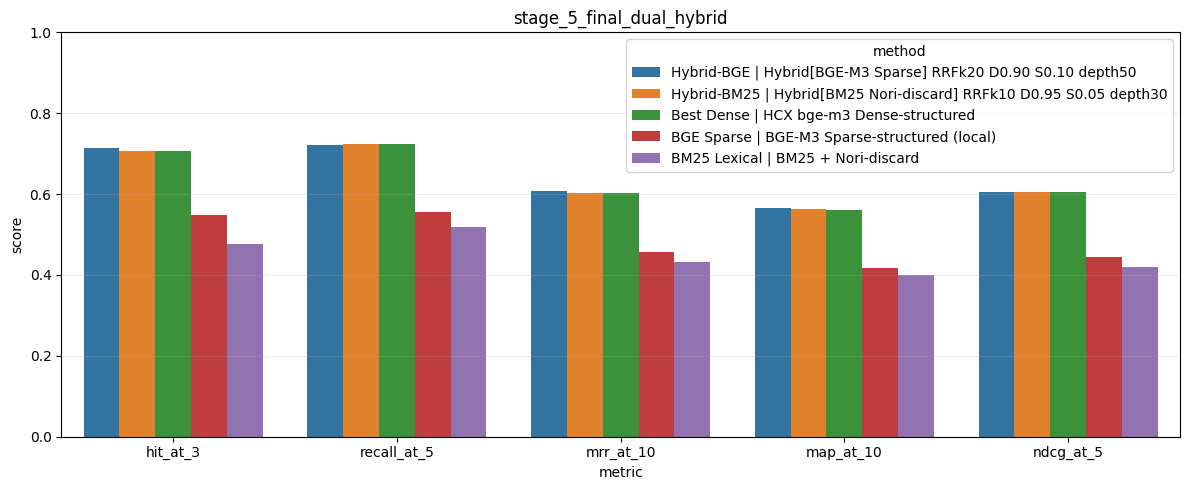

최종 검색 방식: Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50


In [ ]:
stage5_name = "stage_5_final_dual_hybrid"

hybrid_live_by_family = {}
for family, config in best_hybrid_configs_by_family.items():
    sparse_retriever = hybrid_sparse_families[family]["retriever"]
    hybrid_live_by_family[family] = HybridRRFRetriever(
        hybrid_dense_retriever,
        sparse_retriever,
        candidate_depth=config["candidate_depth"],
        rrf_k=int(config["rrf_k"]),
        dense_weight=config["dense_weight"],
        sparse_weight=config["sparse_weight"],
    )

stage5_retrievers = {
    f"Best Dense | {best_dense_method}": best_dense_retriever,
    "BGE Sparse | BGE-M3 Sparse-structured (local)": bge_sparse_retriever,
    f"BM25 Lexical | {BM25_HYBRID_METHOD}": bm25_hybrid_retriever,
    (
        "Hybrid-BGE | "
        f"{best_hybrid_methods_by_family[BGE_SPARSE_FAMILY]}"
    ): hybrid_live_by_family[BGE_SPARSE_FAMILY],
    (
        "Hybrid-BM25 | "
        f"{best_hybrid_methods_by_family[BM25_SPARSE_FAMILY]}"
    ): hybrid_live_by_family[BM25_SPARSE_FAMILY],
}

stage5_results = {
    method: evaluate_and_save(stage5_name, method, retriever)
    for method, retriever in stage5_retrievers.items()
}
best_final_method, stage5_leaderboard = select_stage(
    stage5_name,
    stage5_results,
)
plot_leaderboard(stage5_name)

print("최종 검색 방식:", best_final_method)


## 16. 6차 비교 — 5차 Best 검색기 + BGE Reranker


Reranker 모델 로딩: BAAI/bge-reranker-v2-m3
GPU 사용 가능: True
[stage_6_reranker] No Rerank | Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50 평가 시작


Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 59.17it/s]


[stage_6_reranker] No Rerank | Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50 완료
[stage_6_reranker] BGE Reranker | depth=10 | base=Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50 평가 시작


Compute Scores: 100%|██████████| 2/2 [00:00<00:00, 12.52it/s]


[stage_6_reranker] BGE Reranker | depth=10 | base=Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50 완료
[stage_6_reranker] BGE Reranker | depth=20 | base=Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50 평가 시작


Compute Scores: 100%|██████████| 3/3 [00:00<00:00, 10.81it/s]


[stage_6_reranker] BGE Reranker | depth=20 | base=Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50 완료
[stage_6_reranker] BGE Reranker | depth=30 | base=Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50 평가 시작


Compute Scores: 100%|██████████| 4/4 [00:00<00:00, 11.70it/s]

[stage_6_reranker] BGE Reranker | depth=30 | base=Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50 완료
선정 범위: all(no split column or matching split)
1위: BGE Reranker | depth=30 | base=Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50


,method,ndcg_at_5,recall_at_5,primary_recall_at_5,mrr_at_10,map_at_10,latency_ms_p50,context_limit_exceeded_rate
0,BGE Reranker | depth=30 | base=Hybrid-BGE | Hy...,0.674232,0.796296,0.820899,0.659807,0.627540,624.813575,0.0
1,BGE Reranker | depth=20 | base=Hybrid-BGE | Hy...,0.662328,0.780423,0.805026,0.648233,0.615084,505.473225,0.0
2,BGE Reranker | depth=10 | base=Hybrid-BGE | Hy...,0.643662,0.748413,0.773280,0.631765,0.595025,351.659690,0.0
3,No Rerank | Hybrid-BGE | Hybrid[BGE-M3 Sparse]...,0.606135,0.720899,0.743122,0.606611,0.564714,52.398679,0.0


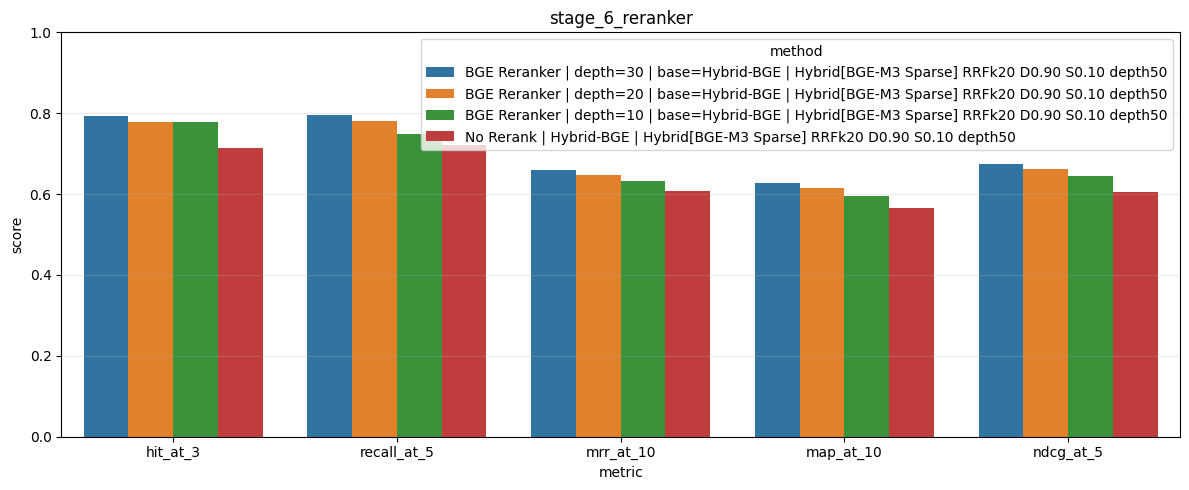

5차 Best 검색기: Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50
6차 최종 파이프라인: BGE Reranker | depth=30 | base=Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50
리랭커 적용 여부: True


,method,reranker_applied,candidate_depth,hit_at_3,recall_at_5,primary_recall_at_5,mrr_at_10,map_at_10,complete_at_5,ndcg_at_5,precision_at_5,useful_precision_at_5,f1_at_5,latency_ms_mean,latency_ms_p50,latency_ms_p95
0,BGE Reranker | depth=30 | base=Hybrid-BGE | Hy...,True,30,0.793651,0.796296,0.820899,0.659807,0.627540,0.409091,0.674232,0.215873,0.215873,0.327192,597.446672,624.813575,707.993474
1,BGE Reranker | depth=20 | base=Hybrid-BGE | Hy...,True,20,0.777778,0.780423,0.805026,0.648233,0.615084,0.409091,0.662328,0.212698,0.212698,0.321901,487.784970,505.473225,604.459552
2,BGE Reranker | depth=10 | base=Hybrid-BGE | Hy...,True,10,0.777778,0.748413,0.773280,0.631765,0.595025,0.386364,0.643662,0.203175,0.203175,0.308125,440.364786,351.659690,533.553804
3,No Rerank | Hybrid-BGE | Hybrid[BGE-M3 Sparse]...,False,10,0.714286,0.720899,0.743122,0.606611,0.564714,0.363636,0.606135,0.190476,0.190476,0.292045,61.713766,52.398679,83.883390


In [ ]:
from FlagEmbedding import FlagReranker

from kdic_retrieval_eval import BGERerankerRetriever

stage6_name = "stage_6_reranker"
best_stage5_retriever = stage5_retrievers[best_final_method]

print("Reranker 모델 로딩:", RERANKER_MODEL_NAME)
print("GPU 사용 가능:", torch.cuda.is_available())

reranker_model = FlagReranker(
    RERANKER_MODEL_NAME,
    use_fp16=torch.cuda.is_available(),
)

stage6_retrievers = {
    f"No Rerank | {best_final_method}": best_stage5_retriever,
}
stage6_configs = {
    f"No Rerank | {best_final_method}": {
        "reranker_applied": False,
        "candidate_depth": CONFIG.evaluation_depth,
        "reranker_model": None,
        "text_mode": None,
    }
}

for candidate_depth in RERANKER_CANDIDATE_DEPTHS:
    method = (
        f"BGE Reranker | depth={candidate_depth} | "
        f"base={best_final_method}"
    )
    stage6_retrievers[method] = BGERerankerRetriever(
        best_stage5_retriever,
        reranker=reranker_model,
        chunks=chunks,
        candidate_depth=candidate_depth,
        text_mode=RERANKER_TEXT_MODE,
        batch_size=RERANKER_BATCH_SIZE,
        max_length=RERANKER_MAX_LENGTH,
        normalize_scores=RERANKER_NORMALIZE_SCORES,
    )
    stage6_configs[method] = {
        "reranker_applied": True,
        "candidate_depth": candidate_depth,
        "reranker_model": RERANKER_MODEL_NAME,
        "text_mode": RERANKER_TEXT_MODE,
    }

stage6_results = {
    method: evaluate_and_save(stage6_name, method, retriever)
    for method, retriever in stage6_retrievers.items()
}
best_reranker_method, stage6_leaderboard = select_stage(
    stage6_name,
    stage6_results,
)

for column in [
    "reranker_applied",
    "candidate_depth",
    "reranker_model",
    "text_mode",
]:
    stage6_leaderboard[column] = stage6_leaderboard["method"].map(
        lambda method: stage6_configs[method][column]
    )

stage6_dir = OUTPUT_ROOT / stage6_name
stage6_leaderboard.to_csv(
    stage6_dir / "leaderboard.csv",
    index=False,
    encoding="utf-8-sig",
)
stage6_leaderboard.to_csv(
    stage6_dir / "reranker_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)
stage_leaderboards[stage6_name] = stage6_leaderboard

plot_leaderboard(stage6_name)

best_reranker_config = stage6_configs[best_reranker_method]
print("5차 Best 검색기:", best_final_method)
print("6차 최종 파이프라인:", best_reranker_method)
print("리랭커 적용 여부:", best_reranker_config["reranker_applied"])

display(
    stage6_leaderboard[
        [
            "method",
            "reranker_applied",
            "candidate_depth",
            "hit_at_3",
            "recall_at_5",
            "primary_recall_at_5",
            "mrr_at_10",
            "map_at_10",
            "complete_at_5",
            "ndcg_at_5",
            "precision_at_5",
            "useful_precision_at_5",
            "f1_at_5",
            "latency_ms_mean",
            "latency_ms_p50",
            "latency_ms_p95",
        ]
    ]
)


## 17. 결과 검증 및 ZIP 패키징


In [ ]:
import importlib.metadata
from dataclasses import asdict
from datetime import datetime, timezone

from kdic_retrieval_eval import zip_results

# 모든 방식의 사용자 반환 청크가 최대 5개인지 검증
for (stage, method), frame in all_method_results.items():
    lengths = frame["retrieved_chunk_ids"].map(
        lambda value: len(json.loads(value))
    )
    if (lengths > CONFIG.final_top_k).any():
        raise AssertionError(f"Top 5 초과 결과 발견: {stage} / {method}")

all_leaderboards = []
for stage, leaderboard in stage_leaderboards.items():
    current = leaderboard.copy()
    current.insert(0, "stage", stage)
    all_leaderboards.append(current)

consolidated = pd.concat(all_leaderboards, ignore_index=True)
consolidated.to_csv(
    OUTPUT_ROOT / "all_stage_leaderboards.csv",
    index=False,
    encoding="utf-8-sig",
)

hybrid_selection_by_family = {
    family: {
        "rrf_stage_method": best_rrf_methods_by_family[family],
        "weight_stage_method": best_weight_methods_by_family[family],
        "final_hybrid_method": best_hybrid_methods_by_family[family],
        **best_hybrid_configs_by_family[family],
    }
    for family in hybrid_sparse_families
}

query_api_rows = hcx_query_embedding_report[
    ~hcx_query_embedding_report["cache_hit"].astype(bool)
]
query_embedding_latency_summary = {
    "question_count": int(len(hcx_query_embedding_report)),
    "api_call_count": int(len(query_api_rows)),
    "cache_hit_count": int(
        hcx_query_embedding_report["cache_hit"].astype(bool).sum()
    ),
    "api_latency_ms_mean": (
        float(query_api_rows["api_latency_ms"].mean())
        if len(query_api_rows)
        else 0.0
    ),
    "api_latency_ms_p50": (
        float(query_api_rows["api_latency_ms"].quantile(0.50))
        if len(query_api_rows)
        else 0.0
    ),
    "api_latency_ms_p95": (
        float(query_api_rows["api_latency_ms"].quantile(0.95))
        if len(query_api_rows)
        else 0.0
    ),
}

final_selection = {
    "best_analyzer": {
        "method": best_analyzer_method,
        "analyzer_mode": best_analyzer_mode,
    },
    "best_sparse_overall": best_sparse_method,
    "best_dense": best_dense_method,
    "dense_embedding": {
        "provider": "CLOVA Studio OpenAI compatibility",
        "base_url": HCX_BASE_URL,
        "model": HCX_EMBEDDING_MODEL,
        "dimensions": HCX_EMBEDDING_DIMENSIONS,
        "content_document_source": hcx_content_documents.source,
        "structured_v1_document_source": hcx_structured_documents.source,
        "structured_v2_document_source": hcx_structured_v2_documents.source,
        "query_embedding_latency_summary": query_embedding_latency_summary,
    },
    "hybrid_dense_selected": HYBRID_DENSE_METHOD,
    "bm25_hybrid_selection": {
        "candidate_methods": bm25_hybrid_candidate_methods,
        "selected_method": BM25_HYBRID_METHOD,
        "selected_analyzer_mode": BM25_HYBRID_MODE,
    },
    "hybrid_by_family": hybrid_selection_by_family,
    "stage5_best_retrieval": best_final_method,
    "reranker_selection": {
        "model": RERANKER_MODEL_NAME,
        "candidate_depths": RERANKER_CANDIDATE_DEPTHS,
        "text_mode": RERANKER_TEXT_MODE,
        "max_length": RERANKER_MAX_LENGTH,
        "batch_size": RERANKER_BATCH_SIZE,
        "normalize_scores": RERANKER_NORMALIZE_SCORES,
        "winner": best_reranker_method,
        **best_reranker_config,
    },
    "final_winner": best_reranker_method,
}

(OUTPUT_ROOT / "final_selection.json").write_text(
    json.dumps(final_selection, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "chunk_count": len(chunks),
    "evaluation_question_count": len(eval_df),
    "excluded_question_count": len(excluded_eval_df),
    "evaluation_source_file": EVAL_XLSX_PATH.name,
    "evaluation_source_sha256": evaluation_source_sha256,
    "evaluation_sheet_name": CONFIG.evaluation_sheet_name,
    "evaluation_normalized_question_count": int(
        (
            evaluation_validation_report["normalization_status"]
            == "normalized"
        ).sum()
    ),
    "evaluation_review_status_filter_applied": (
        CONFIG.allowed_review_statuses is not None
    ),
    "evaluation_normalization_counts": {
        str(key): int(value)
        for key, value in normalization_counts.items()
    },
    "evaluation_exclusion_reason_counts": {
        str(key): int(value)
        for key, value in exclusion_counts.items()
    },
    "structured_v1_corpus_sha256": corpus_fingerprint(
        chunks,
        text_mode="structured",
    ),
    "structured_v2_corpus_sha256": corpus_fingerprint(
        chunks,
        text_mode="structured_v2",
    ),
    "content_corpus_sha256": corpus_fingerprint(
        chunks,
        text_mode="content",
    ),
    "config": asdict(CONFIG),
    "final_output_chunk_count": CONFIG.final_top_k,
    "metric_evaluation_depth": CONFIG.evaluation_depth,
    "dense_embedding_provider": "HCX",
    "hcx_base_url": HCX_BASE_URL,
    "hcx_embedding_model": HCX_EMBEDDING_MODEL,
    "hcx_embedding_dimensions": HCX_EMBEDDING_DIMENSIONS,
    "hcx_content_document_source": hcx_content_documents.source,
    "hcx_structured_v1_document_source": hcx_structured_documents.source,
    "hcx_structured_v2_document_source": hcx_structured_v2_documents.source,
    "hcx_query_embedding_latency_summary": query_embedding_latency_summary,
    "bge_sparse_model_name": BGE_SPARSE_MODEL_NAME,
    "bge_sparse_max_length": BGE_MAX_LENGTH,
    "hybrid_dense_method": HYBRID_DENSE_METHOD,
    "hybrid_sparse_families": {
        family: spec["sparse_method"]
        for family, spec in hybrid_sparse_families.items()
    },
    "hybrid_rrf_k_candidates": RRF_K_CANDIDATES,
    "hybrid_rrf_base_dense_weight": RRF_K_BASE_DENSE_WEIGHT,
    "hybrid_rrf_base_sparse_weight": RRF_K_BASE_SPARSE_WEIGHT,
    "hybrid_rrf_comparison_depth": RRF_K_COMPARISON_DEPTH,
    "hybrid_rrf_selected_by_family": best_rrf_k_by_family,
    "hybrid_weight_pairs": HYBRID_WEIGHT_PAIRS,
    "hybrid_weight_depth": HYBRID_WEIGHT_DEPTH,
    "hybrid_depths": HYBRID_DEPTHS,
    "hybrid_rrf_experiment_count": len(stage40_retrievers),
    "hybrid_weight_experiment_count": len(stage41_retrievers),
    "hybrid_depth_experiment_count": len(stage42_retrievers),
    "reranker_model_name": RERANKER_MODEL_NAME,
    "reranker_candidate_depths": RERANKER_CANDIDATE_DEPTHS,
    "reranker_text_mode": RERANKER_TEXT_MODE,
    "reranker_max_length": RERANKER_MAX_LENGTH,
    "reranker_batch_size": RERANKER_BATCH_SIZE,
    "reranker_normalize_scores": RERANKER_NORMALIZE_SCORES,
    "reranker_experiment_count": len(stage6_retrievers),
    "bm25f_field_boosts": BM25F_FIELD_BOOSTS,
    "selections": selection_records,
    "final_selection": final_selection,
    "versions": {
        "elasticsearch_server": es.info()["version"]["number"],
        "elasticsearch_python": importlib.metadata.version("elasticsearch"),
        "openai": importlib.metadata.version("openai"),
        "FlagEmbedding": importlib.metadata.version("FlagEmbedding"),
        "transformers": importlib.metadata.version("transformers"),
        "numpy": importlib.metadata.version("numpy"),
        "pandas": importlib.metadata.version("pandas"),
        "torch": importlib.metadata.version("torch"),
    },
}

(OUTPUT_ROOT / "run_manifest.json").write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

zip_path = zip_results(
    OUTPUT_ROOT,
    Path(
        "./KDIC_retrieval_6stage_hcx_dense_structured_v2_rrfk_"
        "dual_hybrid_reranker_results.zip"
    ),
)

print("1차 Best Analyzer:", best_analyzer_mode)
print("2차 Best Sparse Overall:", best_sparse_method)
print("3차 Best HCX Dense:", best_dense_method)
print("Hybrid Dense 선택:", HYBRID_DENSE_METHOD)
print("Hybrid BM25 선택:", BM25_HYBRID_METHOD)

for family in hybrid_sparse_families:
    print(
        f"4-0차 {family} Best RRF_K:",
        best_rrf_k_by_family[family],
    )
    print(
        f"4차 {family} Best Hybrid:",
        best_hybrid_methods_by_family[family],
    )

print("5차 Best 검색기:", best_final_method)
print("6차 최종 파이프라인:", best_reranker_method)
print("리랭커 적용 여부:", best_reranker_config["reranker_applied"])
print("최종 반환 청크 수:", CONFIG.final_top_k)
print("결과 ZIP:", zip_path.resolve())

display(
    stage6_leaderboard[
        [
            "method",
            "reranker_applied",
            "candidate_depth",
            "hit_at_3",
            "recall_at_5",
            "primary_recall_at_5",
            "mrr_at_10",
            "map_at_10",
            "complete_at_5",
            "ndcg_at_5",
            "precision_at_5",
            "useful_precision_at_5",
            "f1_at_5",
            "latency_ms_mean",
            "latency_ms_p50",
            "latency_ms_p95",
            "context_limit_exceeded_rate",
        ]
    ]
)


1차 Best Analyzer: discard
2차 Best Sparse Overall: BGE-M3 Sparse-structured (local)
3차 Best HCX Dense: HCX bge-m3 Dense-structured
Hybrid Dense 고정: HCX bge-m3 Dense-structured
Hybrid BM25 선택: BM25 + Nori-discard
4-0차 BGE-M3 Sparse Best RRF_K: 20
4차 BGE-M3 Sparse Best Hybrid: Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50
4-0차 BM25 Nori-discard Best RRF_K: 10
4차 BM25 Nori-discard Best Hybrid: Hybrid[BM25 Nori-discard] RRFk10 D0.95 S0.05 depth30
5차 Best 검색기: Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50
6차 최종 파이프라인: BGE Reranker | depth=30 | base=Hybrid-BGE | Hybrid[BGE-M3 Sparse] RRFk20 D0.90 S0.10 depth50
리랭커 적용 여부: True
최종 반환 청크 수: 5
결과 ZIP: /content/KDIC_retrieval_6stage_hcx_rrfk_dual_hybrid_reranker_results.zip


,method,reranker_applied,candidate_depth,hit_at_3,recall_at_5,primary_recall_at_5,mrr_at_10,map_at_10,complete_at_5,ndcg_at_5,precision_at_5,useful_precision_at_5,f1_at_5,latency_ms_mean,latency_ms_p50,latency_ms_p95,context_limit_exceeded_rate
0,BGE Reranker | depth=30 | base=Hybrid-BGE | Hy...,True,30,0.793651,0.796296,0.820899,0.659807,0.627540,0.409091,0.674232,0.215873,0.215873,0.327192,597.446672,624.813575,707.993474,0.0
1,BGE Reranker | depth=20 | base=Hybrid-BGE | Hy...,True,20,0.777778,0.780423,0.805026,0.648233,0.615084,0.409091,0.662328,0.212698,0.212698,0.321901,487.784970,505.473225,604.459552,0.0
2,BGE Reranker | depth=10 | base=Hybrid-BGE | Hy...,True,10,0.777778,0.748413,0.773280,0.631765,0.595025,0.386364,0.643662,0.203175,0.203175,0.308125,440.364786,351.659690,533.553804,0.0
3,No Rerank | Hybrid-BGE | Hybrid[BGE-M3 Sparse]...,False,10,0.714286,0.720899,0.743122,0.606611,0.564714,0.363636,0.606135,0.190476,0.190476,0.292045,61.713766,52.398679,83.883390,0.0


In [ ]:

# Colab에서 결과 ZIP 자동 다운로드
if IS_COLAB:
    from google.colab import files
    files.download(str(zip_path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 18. 최종 파이프라인 실패 문항 확인


In [ ]:

final_results = stage6_results[best_reranker_method].copy()
failure_columns = [
    column
    for column in [
        "evaluation_id",
        "question",
        "gold_business_function",
        "question_complexity",
        "gold_chunk_ids",
        "retrieved_chunk_ids",
        "evaluation_ranked_chunk_ids",
        "hit_at_3",
        "recall_at_5",
        "primary_recall_at_5",
        "mrr_at_10",
        "ndcg_at_5",
        "context_tokens",
        "context_limit_exceeded",
    ]
    if column in final_results.columns
]
failures = final_results.sort_values(
    ["hit_at_3", "recall_at_5", "ndcg_at_5", "mrr_at_10"],
    ascending=[True, True, True, True],
)
display(failures[failure_columns].head(30))


,evaluation_id,question,gold_business_function,gold_chunk_ids,retrieved_chunk_ids,evaluation_ranked_chunk_ids,hit_at_3,recall_at_5,primary_recall_at_5,mrr_at_10,ndcg_at_5,context_tokens,context_limit_exceeded
6,EVAL007,어떤 금융회사가 예금보호 대상인가요?,deposit_protection,"[""DP-003_chunk_002""]","[""DP-006_chunk_002"", ""DP-006_chunk_003"", ""DP-0...","[""DP-006_chunk_002"", ""DP-006_chunk_003"", ""DP-0...",0.0,0.000000,0.000000,0.000000,0.000000,2016,0
8,EVAL009,증권사는 예금보호 대상에 포함되나요?,deposit_protection,"[""DP-003_chunk_002""]","[""DP-006_chunk_002"", ""DP-006_chunk_003"", ""DP-0...","[""DP-006_chunk_002"", ""DP-006_chunk_003"", ""DP-0...",0.0,0.000000,0.000000,0.000000,0.000000,2035,0
12,EVAL013,은행이 영업정지되면 제 예금은 예금자보호제도에 따라 어떻게 보호되나요?,deposit_protection,"[""DP-005_chunk_004""]","[""DP-002_chunk_001"", ""DP-005_chunk_014"", ""DP-0...","[""DP-002_chunk_001"", ""DP-005_chunk_014"", ""DP-0...",0.0,0.000000,0.000000,0.000000,0.000000,2928,0
29,EVAL030,은행이 파산했다는데 예금보험금을 받으려면 무엇부터 해야 하나요?,deposit_insurance_payout,"[""BI-002_chunk_000"", ""BI-002_chunk_001"", ""BI-0...","[""DP-005_chunk_021"", ""DP-006_chunk_015"", ""BI-0...","[""DP-005_chunk_021"", ""DP-006_chunk_015"", ""BI-0...",0.0,0.000000,0.000000,0.000000,0.000000,2049,0
32,EVAL033,예금보험금을 본인이 직접 신청하지 못할 때 가족이 대신 신청할 수 있나요?,deposit_insurance_payout,"[""BI-001_chunk_001"", ""BI-001_chunk_006""]","[""BI-001_chunk_004"", ""DP-005_chunk_033"", ""BI-0...","[""BI-001_chunk_004"", ""DP-005_chunk_033"", ""BI-0...",0.0,0.000000,0.000000,0.000000,0.000000,4068,0
42,EVAL043,법인 명의로 남아있는 미수령금도 조회·신청이 가능한가요?,unclaimed_funds,"[""DP-006_chunk_012"", ""MT-008_chunk_002""]","[""UN-004_chunk_002"", ""UN-002_chunk_000"", ""UN-0...","[""UN-004_chunk_002"", ""UN-002_chunk_000"", ""UN-0...",0.0,0.000000,0.000000,0.000000,0.000000,2112,0
45,EVAL046,이미 폐업한 저축은행의 미수령금도 예금보험공사가 대신 지급하나요?,unclaimed_funds,"[""BI-003_chunk_005"", ""UN-001_chunk_003""]","[""UN-004_chunk_000"", ""UN-003_chunk_001"", ""DP-0...","[""UN-004_chunk_000"", ""UN-003_chunk_001"", ""DP-0...",0.0,0.000000,0.000000,0.000000,0.000000,2227,0
49,EVAL050,부모님이 이런걸 잘 못해서 내가 대신해서 미수령금을 찾을 수 있어?,unclaimed_funds,"[""BI-001_chunk_001"", ""MT-008_chunk_001"", ""MT-0...","[""DP-005_chunk_026"", ""UN-001_chunk_000"", ""UN-0...","[""DP-005_chunk_026"", ""UN-001_chunk_000"", ""UN-0...",0.0,0.000000,0.000000,0.000000,0.000000,2000,0
74,EVAL076,착오송금 반환지원의 법적 근거가 뭔가요?,mistaken_transfer,"[""MT-010_chunk_002"", ""MT-010_chunk_003"", ""MT-0...","[""MT-010_rule_layer01_chunk_000"", ""MT-010_rule...","[""MT-010_rule_layer01_chunk_000"", ""MT-010_rule...",0.0,0.000000,0.000000,0.000000,0.000000,1730,0
78,EVAL080,착오송금 반환지원 방문 접수센터의 운영시간은 어떻게 되나요?,mistaken_transfer,"[""MT-012_chunk_001""]","[""MT-012_chunk_000"", ""MT-006_chunk_000"", ""MT-0...","[""MT-012_chunk_000"", ""MT-006_chunk_000"", ""MT-0...",0.0,0.000000,0.000000,0.000000,0.000000,1633,0


## 결과 파일 구조

```text
kdic_retrieval_results_6stage_hcx_dense_structured_v2_rrfk_dual_hybrid_reranker/
├─ evaluation_dataset_included.csv
├─ evaluation_dataset_excluded.csv
├─ evaluation_dataset_validation.csv
├─ hcx_document_embedding_content_report.csv
├─ hcx_document_embedding_structured_report.csv
├─ hcx_document_embedding_structured_v2_report.csv
├─ hcx_structured_v2_field_coverage.csv
├─ hcx_structured_v2_preview.csv
├─ hcx_query_embedding_latency.csv
├─ stage_1_analyzer/
├─ stage_2_sparse/
├─ stage_3_dense_hcx/
│  ├─ leaderboard.csv
│  ├─ selection_log.json
│  ├─ metric_comparison.png
│  ├─ HCX_bge-m3_Dense-content/
│  ├─ HCX_bge-m3_Dense-structured-v1/
│  └─ HCX_bge-m3_Dense-structured-v2/
├─ stage_4_0_dual_hybrid_rrf_k/
│  ├─ leaderboard.csv
│  ├─ rrf_k_comparison.csv
│  ├─ family_winners.csv
│  └─ metric_comparison.png
├─ stage_4_1_dual_hybrid_weights/
├─ stage_4_2_dual_hybrid_depth/
├─ stage_5_final_dual_hybrid/
├─ stage_6_reranker/
├─ all_stage_leaderboards.csv
├─ final_selection.json
└─ run_manifest.json
```

- `hcx_structured_v2_field_coverage.csv`: Structured V2 메타데이터 필드별 실제 보유 청크 수와 커버리지
- `hcx_structured_v2_preview.csv`: 첫 20개 청크의 Structured V2 임베딩 입력 확인용
- `stage_3_dense_hcx/leaderboard.csv`: Content, Structured V1, Structured V2의 Dense 성능 비교
- 3차 Dense 승자는 `HYBRID_DENSE_METHOD`와 `hybrid_dense_retriever`로 4단계에 자동 전달됩니다.
- `rrf_k_comparison.csv`: 두 Hybrid 계열 × 7개 RRF_K, 총 14개 결과
- `hybrid_weight_comparison.csv`: 계열별 Best RRF_K를 적용한 두 계열 × 8개 가중치, 총 16개 결과
- `hybrid_depth_comparison.csv`: 계열별 Best RRF_K·가중치에 depth 20/30/50을 적용한 6개 결과
- `hcx_query_embedding_latency.csv`: HCX 질문 임베딩 API 호출 시간과 캐시 사용 여부
- `stage_6_reranker/reranker_comparison.csv`: 리랭커 미적용과 후보 depth 10/20/30 비교 결과
- `question_results.csv`: 문항별 Gold, 최종 Top 5, 평가용 Top 10, 지표와 검색·리랭킹 지연시간

최종 ZIP 파일명은
`KDIC_retrieval_6stage_hcx_dense_structured_v2_rrfk_dual_hybrid_reranker_results.zip`입니다.
